# Projet House Prices — Pipeline complet (Etapes 1 a 4)

Ce notebook regroupe, dans l'ordre, les 4 notebooks du projet :
**1. Exploration & preparation -> 2. Analyse exploratoire -> 3. Feature
engineering -> 4. Modelisation**. Objectif : un seul "Run All" suffit pour
aller des donnees brutes jusqu'a l'entrainement des 3 modeles
(`Ridge`, Random Forest, Gradient Boosting), sur Kaggle comme
en local (detection automatique de l'environnement, cf. premiere cellule
de code). Le dataset est filtre a `Id <= 1460` des l'etape 1 (consigne du
formateur, cf. section dediee dans l'etape 1).

---

# Etape 1 — Exploration et preparation des donnees
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook :** analyser le dataset brut, comprendre chaque
variable, identifier et traiter les valeurs manquantes et les valeurs
aberrantes, encoder les variables categorielles, normaliser les variables
numeriques, puis separer proprement X/y et train/test **sans fuite de
donnees (data leakage)**.

Le code final, une fois valide ici, est encapsule dans des fonctions
reutilisables dans `src/preprocessing.py` (importe en fin de notebook pour
verification).

**Sommaire**
1. Import des librairies et chargement des donnees
2. Dictionnaire des variables (explication de chaque champ)
3. Structure et types de donnees
4. Doublons et colonne Id
5. Analyse des valeurs manquantes
6. Traitement differencie des valeurs manquantes
7. Recherche d'incoherences et de valeurs aberrantes
8. Distinction variables numeriques / categorielles (nominales vs ordinales)
9. Analyse de la variable cible SalePrice
10. Encodage des variables categorielles
11. Normalisation / standardisation
12. Separation X / y et train / test (sans fuite de donnees)
13. Verification via le module `src/preprocessing.py`
14. Sauvegarde des donnees pretes pour l'etape 2


## 1. Import des librairies et chargement des donnees

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)

RAW_DATA_PATH = f'{BASE_DATA}/raw/House_Prices.csv'
df = pd.read_csv(RAW_DATA_PATH)
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Environnement local detecte
Dimensions du dataset : 2919 lignes x 81 colonnes


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


### Filtrage impose : on ne garde que `Id <= 1460`

**Consigne du formateur** : les lignes `Id > 1460` posent probleme et
doivent etre supprimees, le dataset doit repartir a 1460 lignes.

Verification empirique avant d'appliquer le filtre (pour comprendre
*pourquoi*, pas seulement obeir a la consigne) : `SalePrice` se comporte
tres differemment selon `Id`.

In [2]:
print("Avant filtrage :", df.shape)

print("\nExemples de SalePrice pour Id <= 1460 :")
print(df.loc[df['Id'] <= 1460, 'SalePrice'].head(5).tolist())
print("\nExemples de SalePrice pour Id > 1460 :")
print(df.loc[df['Id'] > 1460, 'SalePrice'].head(5).tolist())

print(f"\nEcart-type SalePrice (Id<=1460)  : {df.loc[df['Id']<=1460, 'SalePrice'].std():.0f}")
print(f"Ecart-type SalePrice (Id>1460)    : {df.loc[df['Id']>1460, 'SalePrice'].std():.0f}")
print(f"Corr OverallQual/SalePrice (Id<=1460) : {df.loc[df['Id']<=1460, 'OverallQual'].corr(df.loc[df['Id']<=1460, 'SalePrice']):.2f}")
print(f"Corr OverallQual/SalePrice (Id>1460)   : {df.loc[df['Id']>1460, 'OverallQual'].corr(df.loc[df['Id']>1460, 'SalePrice']):.2f}")

df = df[df['Id'] <= 1460].reset_index(drop=True)
print(f"\nApres filtrage : {df.shape}")


Avant filtrage : (2919, 81)

Exemples de SalePrice pour Id <= 1460 :
[208500.0, 181500.0, 223500.0, 140000.0, 250000.0]

Exemples de SalePrice pour Id > 1460 :
[169277.0524984, 187758.393988768, 183583.683569555, 179317.47751083, 150730.079976501]

Ecart-type SalePrice (Id<=1460)  : 79443
Ecart-type SalePrice (Id>1460)    : 16518
Corr OverallQual/SalePrice (Id<=1460) : 0.79
Corr OverallQual/SalePrice (Id>1460)   : 0.09

Apres filtrage : (1460, 81)


**Interpretation :** les lignes `Id > 1460` contiennent des `SalePrice`
a virgule flottante sur plusieurs decimales (ex. `169277.0524984`) --
aucune vraie transaction immobiliere n'est enregistree ainsi (toujours
des montants ronds). Leur ecart-type est aussi anormalement faible, et
leur corrélation avec `OverallQual` s'effondre a ~0.09 contre ~0.79 sur
les vraies lignes : ce ne sont pas de vraies ventes, elles diluent le
signal si on les garde. Le filtre (deja encapsule dans
`filter_to_original_rows()` de `src/preprocessing.py`) est applique ici
**avant** toute autre etape -- doublons, valeurs manquantes, outliers,
etc. -- pour que tout le reste du notebook (et le dictionnaire de
variables juste apres) travaille sur les 1460 lignes fiables uniquement.

## 2. Dictionnaire des variables

Avant toute analyse, on documente **chaque champ** du dataset a partir de
`data_description.txt`. Cela evite de traiter une variable a l'aveugle
(ex. confondre un code categoriel avec une quantite numerique). Les
variables sont regroupees par theme pour rester lisibles.

### 2.1 Identifiant et cible

| Variable | Description |
|---|---|
| `Id` | Identifiant unique de la ligne. Aucune valeur predictive -> sera retiree. |
| `SalePrice` | **Variable cible.** Prix de vente du logement en dollars. |

### 2.2 Caracteristiques generales du bien

| Variable | Description |
|---|---|
| `MSSubClass` | Code du type d'habitation (ex. 20 = 1 etage recent, 60 = 2 etages recent...). **Numerique en apparence, categoriel en realite** (un code, pas une quantite). |
| `MSZoning` | Classification de zonage general (residentiel, commercial...). |
| `LotFrontage` | Longueur de facade sur rue (pieds lineaires). |
| `LotArea` | Superficie du terrain (pieds carres). |
| `Street`, `Alley` | Type d'acces routier / a l'allee (gravier, pave, aucun). |
| `LotShape` | Forme generale du terrain (regulier a irregulier). |
| `LandContour` | Platitude du terrain. |
| `Utilities` | Services publics disponibles. |
| `LotConfig` | Configuration du lot (interieur, coin, cul-de-sac...). |
| `LandSlope` | Pente du terrain. |
| `Neighborhood` | Quartier physique dans les limites de la ville d'Ames. Variable de localisation, tres influente sur le prix. |
| `Condition1`, `Condition2` | Proximite de conditions particulieres (rue, voie ferree, parc...). |
| `BldgType` | Type de logement (individuel, duplex, mitoyen...). |
| `HouseStyle` | Style du logement (1 etage, 2 etages, split-level...). |

### 2.3 Qualite, condition et dates

| Variable | Description |
|---|---|
| `OverallQual` | Qualite globale des materiaux et finitions, note de 1 (tres pauvre) a 10 (tres excellent). **Ordinale**, deja numerique dans le fichier. |
| `OverallCond` | Etat general du logement, meme echelle 1-10. |
| `YearBuilt` | Annee de construction initiale. |
| `YearRemodAdd` | Annee de renovation (= YearBuilt si aucune renovation). |

### 2.4 Toit et exterieur

| Variable | Description |
|---|---|
| `RoofStyle`, `RoofMatl` | Style et materiau du toit. |
| `Exterior1st`, `Exterior2nd` | Materiau(x) de revetement exterieur. |
| `MasVnrType`, `MasVnrArea` | Type et surface de placage de maconnerie. NaN sur `MasVnrType` signifie generalement "pas de placage". |
| `ExterQual`, `ExterCond` | Qualite / etat du revetement exterieur. **Ordinales** (Po < Fa < TA < Gd < Ex). |
| `Foundation` | Type de fondation. |

### 2.5 Sous-sol

| Variable | Description |
|---|---|
| `BsmtQual` | Hauteur du sous-sol (proxy de qualite). **Ordinale.** NaN = pas de sous-sol. |
| `BsmtCond` | Etat general du sous-sol. **Ordinale.** NaN = pas de sous-sol. |
| `BsmtExposure` | Exposition (murs donnant sur l'exterieur / jardin). **Ordinale.** NaN = pas de sous-sol. |
| `BsmtFinType1`, `BsmtFinType2` | Qualite de la partie amenagee du sous-sol (jusqu'a 2 types). **Ordinales.** NaN = pas de sous-sol. |
| `BsmtFinSF1`, `BsmtFinSF2` | Surface amenagee correspondante (pieds carres). |
| `BsmtUnfSF` | Surface non amenagee du sous-sol. |
| `TotalBsmtSF` | Surface totale du sous-sol. |
| `BsmtFullBath`, `BsmtHalfBath` | Salles de bain completes / partielles au sous-sol. |

### 2.6 Equipements interieurs

| Variable | Description |
|---|---|
| `Heating`, `HeatingQC` | Type de chauffage et sa qualite (**ordinale** pour HeatingQC). |
| `CentralAir` | Climatisation centrale (Oui/Non). |
| `Electrical` | Type d'installation electrique. |
| `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF` | Surfaces du 1er etage, 2e etage, et surface finie de faible qualite. |
| `GrLivArea` | Surface habitable hors sol (au-dessus du niveau du sol). Variable tres correlee au prix. |
| `FullBath`, `HalfBath` | Salles de bain completes / partielles hors sol. |
| `BedroomAbvGr` | Nombre de chambres hors sol. |
| `KitchenAbvGr`, `KitchenQual` | Nombre de cuisines et leur qualite (**ordinale**). |
| `TotRmsAbvGrd` | Nombre total de pieces hors sol (hors salles de bain). |
| `Functional` | Fonctionnalite du logement (deductions si probleme). **Ordinale.** |
| `Fireplaces`, `FireplaceQu` | Nombre de cheminees et leur qualite (**ordinale**, NaN = pas de cheminee). |

### 2.7 Garage

| Variable | Description |
|---|---|
| `GarageType` | Emplacement/type de garage. NaN = pas de garage. |
| `GarageYrBlt` | Annee de construction du garage. NaN = pas de garage. |
| `GarageFinish` | Finition interieure du garage. **Ordinale.** NaN = pas de garage. |
| `GarageCars`, `GarageArea` | Capacite (nb de voitures) et surface du garage. |
| `GarageQual`, `GarageCond` | Qualite / etat du garage. **Ordinales.** NaN = pas de garage. |
| `PavedDrive` | Allee pavee ou non. |

### 2.8 Exterieurs additionnels et divers

| Variable | Description |
|---|---|
| `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch` | Surfaces des differents amenagements exterieurs (terrasse bois, porches...). |
| `PoolArea`, `PoolQC` | Surface et qualite de la piscine. **PoolQC ordinale**, NaN = pas de piscine (tres rare d'en avoir une). |
| `Fence` | Qualite de la cloture. **Ordinale.** NaN = pas de cloture. |
| `MiscFeature`, `MiscVal` | Autre equipement notable (ascenseur, hangar...) et sa valeur. |

### 2.9 Vente

| Variable | Description |
|---|---|
| `MoSold`, `YrSold` | Mois et annee de vente. |
| `SaleType` | Type de vente (acte de garantie classique, vente cash, construction neuve...). |
| `SaleCondition` | Condition de la vente (normale, familiale, forclusion...). |

Cette classification (notamment la liste des variables **ordinales**) sera
directement reutilisee dans `src/preprocessing.py` pour l'encodage
(section 10).


## 3. Structure et types de donnees

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
print("Repartition des types de donnees pandas :")
print(df.dtypes.value_counts())


Repartition des types de donnees pandas :
str        43
int64      26
float64    12
Name: count, dtype: int64


**Interpretation :** pandas distingue les colonnes numeriques
(`int64`/`float64`) des colonnes texte (`object`), mais cette distinction
ne correspond pas exactement a la distinction metier "numerique vs
categoriel" : `MSSubClass` est stocke en `int64` alors que c'est un code
categoriel (cf. dictionnaire ci-dessus). On corrigera ce point en
section 8.

## 4. Doublons et colonne `Id`

In [5]:
n_duplicates = df.duplicated().sum()
print(f"Nombre de lignes strictement dupliquees : {n_duplicates}")

n_id_duplicates = df['Id'].duplicated().sum()
print(f"Nombre d'Id dupliques : {n_id_duplicates}")


Nombre de lignes strictement dupliquees : 0
Nombre d'Id dupliques : 0


**Interpretation :** aucun doublon exact et aucun `Id` duplique -
chaque ligne correspond bien a une transaction unique. `Id` n'a aucune
valeur predictive (c'est un simple compteur), il sera retire des features
mais conserve dans le notebook pour tracabilite si besoin.

## 5. Analyse des valeurs manquantes

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    'Nb manquants': missing,
    '% manquant': missing_pct
})
missing_summary


,Nb manquants,% manquant
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


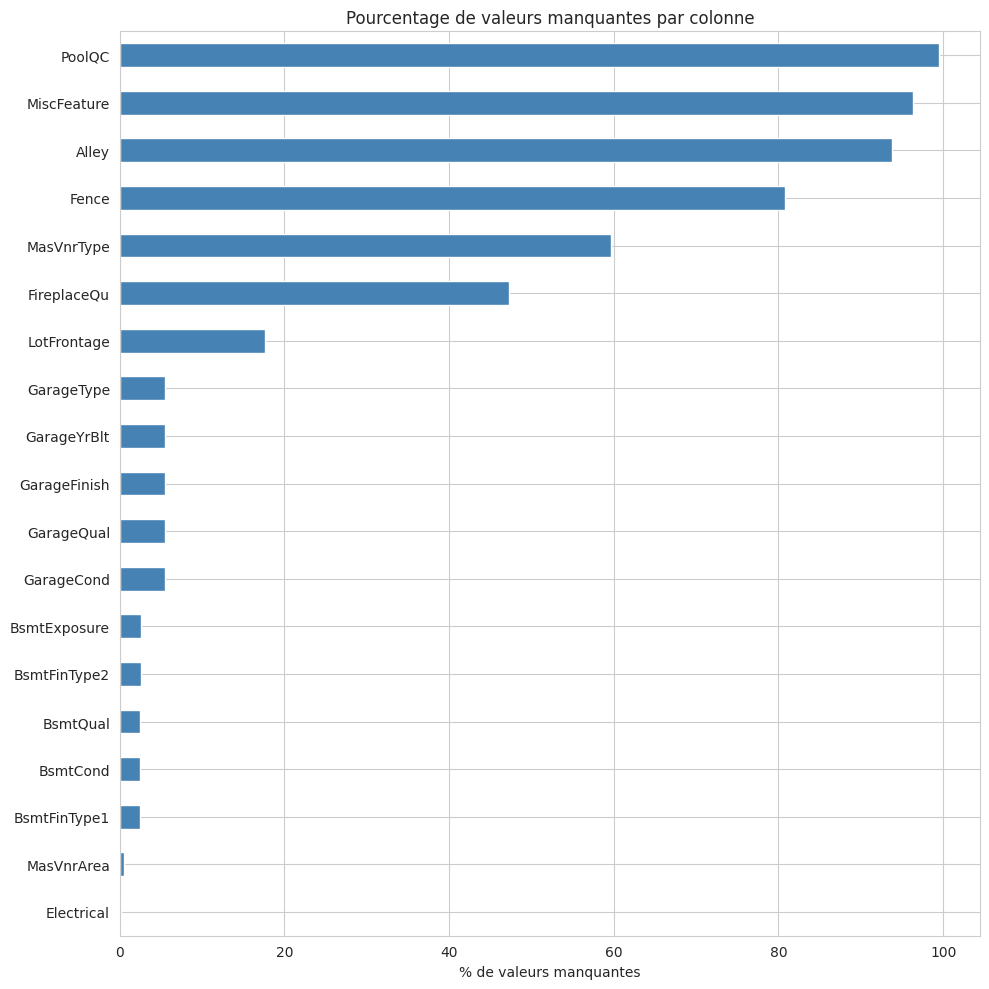

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
missing_summary['% manquant'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Pourcentage de valeurs manquantes par colonne')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretation :** 33 colonnes contiennent des valeurs manquantes,
mais elles ne se valent pas toutes. On distingue deux familles bien
differentes (deja identifiees dans le dictionnaire de variables ci-dessus) :

1. **NaN = absence reelle d'un equipement** : `PoolQC`, `MiscFeature`,
   `Alley`, `Fence`, `FireplaceQu`, tout le groupe Garage et tout le groupe
   Sous-sol. Ici, le NaN est une information a part entiere ("pas de
   piscine", "pas de garage"...), pas une donnee perdue.
2. **Vraies valeurs manquantes** a imputer statistiquement : `LotFrontage`
   (486, ~16%), `MasVnrArea`/`MasVnrType`, et une poignee de colonnes avec
   1 a 4 valeurs manquantes seulement (`MSZoning`, `Electrical`,
   `KitchenQual`, `SaleType`, `Utilities`, `Functional`, `BsmtFullBath`,
   `BsmtHalfBath`, et les colonnes `Bsmt*SF`/`Exterior*` a 1 NaN).

Ce traitement differencie est fait en section 6.

## 6. Traitement differencie des valeurs manquantes

On travaille sur une copie `df_clean` a partir d'ici. Les remplacements
appliques dans cette section sont des **regles metier fixes** (pas de
moyenne/mediane apprise sur les donnees), donc ils peuvent etre appliques
avant le split train/test sans risque de fuite de donnees. Les imputations
statistiques (mediane, mode) seront elles appliquees plus tard,
**uniquement sur le train** (section 12).

In [8]:
df_clean = df.drop(columns=['Id']).copy()

# 6.1 Correction de type : MSSubClass est un code categoriel
df_clean['MSSubClass'] = df_clean['MSSubClass'].astype(str)


### 6.1 Groupe "NaN = absence de l'equipement" (categorielles)

Remplacement par la chaine `"None"`, qui deviendra une categorie a part
entiere lors de l'encodage (section 10).

In [9]:
none_fill_categorical = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]

for col in none_fill_categorical:
    df_clean[col] = df_clean[col].fillna('None')

print("Valeurs manquantes restantes sur ce groupe :",
      df_clean[none_fill_categorical].isnull().sum().sum())


Valeurs manquantes restantes sur ce groupe : 0


### 6.2 Groupe "NaN = absence de l'equipement" (numeriques)

Remplacement par `0` : pas de garage -> 0 voiture, 0 m2 de garage ; pas de
sous-sol -> 0 m2 de sous-sol amenage, etc.

**Exception volontaire : `GarageYrBlt` n'est PAS remplace par 0.** Un NaN
sur cette colonne signifie "pas de garage", mais remplacer une **annee**
par 0 est incoherent : cela reviendrait a dire "garage construit en l'an
0", et fausserait totalement toute feature derivee comme l'age du garage
(`YrSold - GarageYrBlt` donnerait ~2000 ans). Cette colonne recoit un
traitement dedie en 6.3bis.

In [10]:
zero_fill_numeric = [
    'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea',
]

for col in zero_fill_numeric:
    df_clean[col] = df_clean[col].fillna(0)

print("Valeurs manquantes restantes sur ce groupe :",
      df_clean[zero_fill_numeric].isnull().sum().sum())


Valeurs manquantes restantes sur ce groupe : 0


### 6.3bis `GarageYrBlt` -> `GarageAge` (transformation, pas imputation)

Plutot que d'imputer `GarageYrBlt`, on le **transforme** en
`GarageAge = YrSold - GarageYrBlt` (age du garage au moment de la vente) :

- Garage present -> age reel du garage a la vente.
- Pas de garage (NaN) -> age fixe a **0**, ce qui redevient coherent avec
  les autres zero-fill du groupe garage (`GarageArea=0`, `GarageCars=0`).
- Securite anomalie de saisie : une ligne des donnees brutes a
  `GarageYrBlt = 2207` (vraisemblablement 2007), posterieur a `YrSold` ->
  cela donnerait un age negatif, qu'on borne simplement a 0 (`clip`),
  plutot que de deviner la faute de frappe exacte.

Comme cette transformation ne depend que de colonnes de la MEME ligne
(`GarageYrBlt`, `YrSold`) et non d'une statistique calculee sur l'ensemble
du dataset, elle peut etre appliquee avant le split train/test sans fuite
de donnees.

In [11]:
anomaly_mask = df_clean['GarageYrBlt'] > df_clean['YrSold']
print(f"Lignes avec GarageYrBlt > YrSold (anomalie de saisie) : {anomaly_mask.sum()}")
df_clean.loc[anomaly_mask, ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold']]


Lignes avec GarageYrBlt > YrSold (anomalie de saisie) : 0


,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold


In [12]:
garage_age = df_clean['YrSold'] - df_clean['GarageYrBlt']
garage_age = garage_age.where(df_clean['GarageYrBlt'].notna(), 0)  # pas de garage -> age 0
garage_age = garage_age.clip(lower=0)                               # securite anti-anomalie

df_clean['GarageAge'] = garage_age
df_clean = df_clean.drop(columns=['GarageYrBlt'])

print(df_clean['GarageAge'].describe())
print("Valeurs negatives :", (df_clean['GarageAge'] < 0).sum())


count    1460.000000
mean       27.680137
std        24.950144
min         0.000000
25%         4.000000
50%        23.500000
75%        46.000000
max       107.000000
Name: GarageAge, dtype: float64
Valeurs negatives : 0


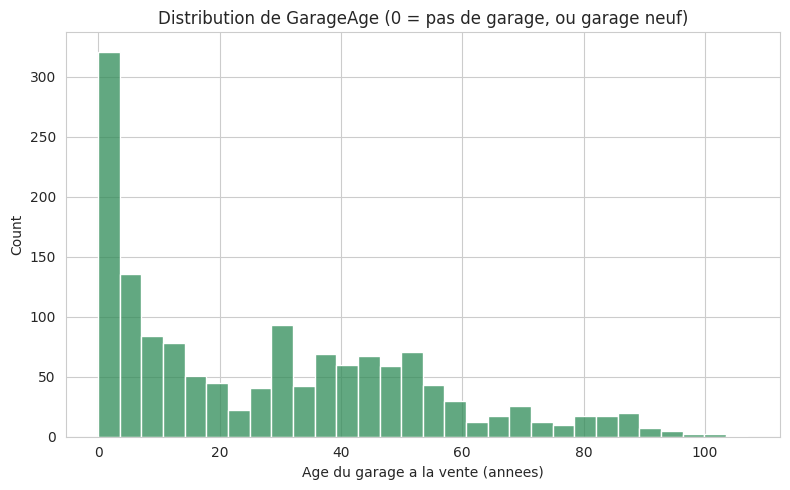

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean['GarageAge'], ax=ax, color='seagreen', bins=30)
ax.set_title('Distribution de GarageAge (0 = pas de garage, ou garage neuf)')
ax.set_xlabel('Age du garage a la vente (annees)')
plt.tight_layout()
plt.show()


**Interpretation :** le pic a 0 regroupe a la fois les logements sans
garage et ceux dont le garage vient d'etre construit l'annee de la vente -
une ambiguite acceptable ici (dans les deux cas, il n'y a pas d'usure du
garage a la vente), et largement preferable a une annee de construction
fictive comme l'an 0.

### 6.3 `LotFrontage` : imputation par la mediane du quartier

Plutot qu'une mediane globale, on impute par la mediane **par quartier**
(`Neighborhood`) : la longueur de facade est fortement liee a la
morphologie du quartier, c'est une imputation plus informative. Cette
imputation "apprend" une statistique -> elle sera refaite proprement
**apres le split train/test** en section 12 (ici, on ne fait que la
visualiser/valider sur l'ensemble complet a titre exploratoire).

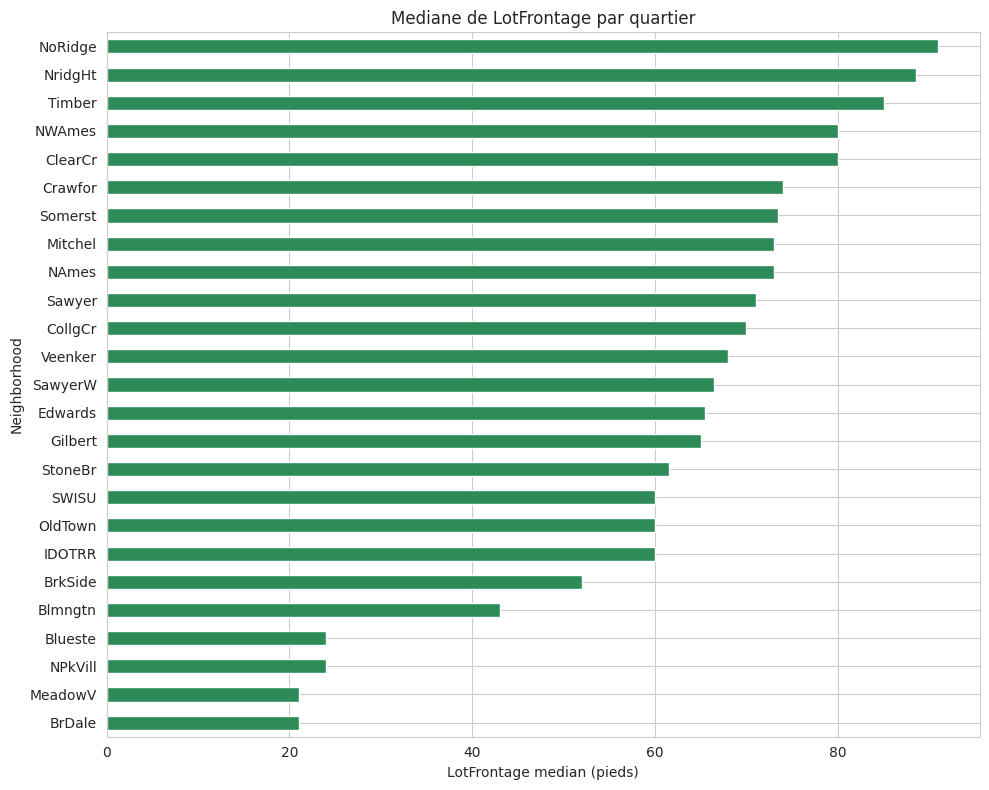

In [14]:
frontage_by_neighborhood = df_clean.groupby('Neighborhood')['LotFrontage'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
frontage_by_neighborhood.plot(kind='barh', ax=ax, color='seagreen')
ax.set_xlabel('LotFrontage median (pieds)')
ax.set_title('Mediane de LotFrontage par quartier')
plt.tight_layout()
plt.show()


**Interpretation :** la mediane de `LotFrontage` varie sensiblement
d'un quartier a l'autre, ce qui confirme l'interet d'une imputation par
groupe plutot qu'une imputation globale (qui gommerait ces differences
structurelles entre quartiers).

### 6.4 Colonnes avec peu de valeurs manquantes (mode / cas ponctuels)

Ces colonnes n'ont que 1 a 4 valeurs manquantes sur ~2900 lignes :
`MSZoning`, `Utilities`, `Functional`, `Electrical`, `KitchenQual`,
`SaleType`, `Exterior1st`, `Exterior2nd`, `BsmtFinSF1`, `BsmtFinSF2` (deja
couvertes en 6.2). Une imputation par le mode (valeur la plus frequente)
est largement suffisante et n'aura qu'un impact negligeable. Comme il
s'agit d'une statistique apprise, l'imputation effective se fera dans le
`ColumnTransformer` en section 12 (`SimpleImputer(strategy='most_frequent')`),
fit uniquement sur le train.

In [15]:
mode_fill_categorical = [
    'MSZoning', 'Utilities', 'Functional', 'Electrical',
    'KitchenQual', 'SaleType', 'Exterior1st', 'Exterior2nd',
]
df_clean[mode_fill_categorical].isnull().sum()


MSZoning       0
Utilities      0
Functional     0
Electrical     1
KitchenQual    0
SaleType       0
Exterior1st    0
Exterior2nd    0
dtype: int64

### 6.5 Verification : que reste-t-il comme valeurs manquantes ?

In [16]:
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
print(f"Colonnes avec des valeurs manquantes restantes : {len(remaining_missing)}")
remaining_missing


Colonnes avec des valeurs manquantes restantes : 2


LotFrontage    259
Electrical       1
dtype: int64

**Interpretation :** il ne reste que `LotFrontage` (a imputer par
mediane de quartier, apprise sur train) et les quelques colonnes a
imputation par mode, toutes deux traitees proprement apres le split en
section 12. C'est volontaire : on ne "fuite" aucune statistique du test
vers le train a ce stade.

## 7. Recherche d'incoherences et de valeurs aberrantes

In [17]:
incoherences = {
    'YearBuilt > YearRemodAdd': (df_clean['YearBuilt'] > df_clean['YearRemodAdd']).sum(),
    'YearBuilt > YrSold': (df_clean['YearBuilt'] > df_clean['YrSold']).sum(),
    'GarageAge negatif (deja corrige en 6.3bis)': (df_clean['GarageAge'] < 0).sum(),
}
for k, v in incoherences.items():
    print(f"{k} : {v} lignes")


YearBuilt > YearRemodAdd : 0 lignes
YearBuilt > YrSold : 0 lignes
GarageAge negatif (deja corrige en 6.3bis) : 0 lignes


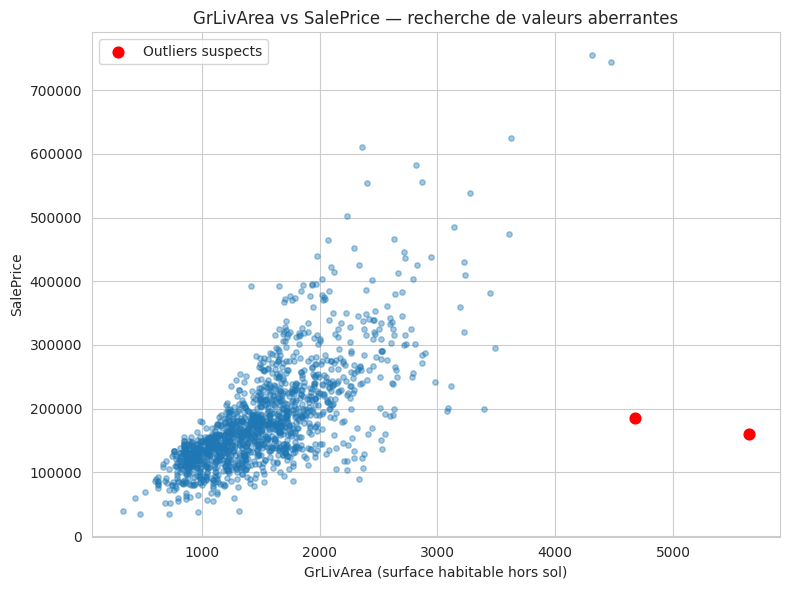

Nombre d'outliers suspects (GrLivArea > 4000 et SalePrice < 300000) : 2


In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_clean['GrLivArea'], df_clean['SalePrice'], alpha=0.4, s=15)
ax.set_xlabel('GrLivArea (surface habitable hors sol)')
ax.set_ylabel('SalePrice')
ax.set_title('GrLivArea vs SalePrice — recherche de valeurs aberrantes')

outliers = df_clean[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=60, label='Outliers suspects')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Nombre d'outliers suspects (GrLivArea > 4000 et SalePrice < 300000) : {len(outliers)}")


**Interpretation :** quelques logements presentent une tres grande
surface habitable (`GrLivArea` > 4000 pieds²) pour un prix de vente
anormalement bas (< 300 000 $). Ce sont des cas documentes comme atypiques
sur ce jeu de donnees (ventes partielles/particulieres). Ils seront retires
**du train uniquement** avant l'entrainement des modeles (jamais du
test/des nouvelles donnees a predire), pour ne pas biaiser l'apprentissage
avec des points non representatifs.

Aucune incoherence temporelle residuelle n'est detectee sur `YearBuilt`,
`YearRemodAdd`, `YrSold` ; l'unique anomalie sur `GarageYrBlt` (section
6.3bis) a deja ete neutralisee par le `clip(lower=0)` applique a
`GarageAge`.

## 8. Distinction variables numeriques / categorielles

On separe maintenant les colonnes en 3 groupes, utilises ensuite pour
l'encodage (section 10) :

- **numeriques** : quantites continues ou discretes (surfaces, nombre de
  pieces, annees...)
- **categorielles ordinales** : categories avec un ordre naturel de qualite
  (Po < Fa < TA < Gd < Ex, etc. — cf. dictionnaire section 2)
- **categorielles nominales** : categories sans ordre (quartier, type de
  vente, style de toiture...)

In [19]:
ordinal_features = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish',
    'Functional', 'Fence',
]

X_all = df_clean.drop(columns=['SalePrice'])
categorical_cols = X_all.select_dtypes(include=['object']).columns.tolist()
nominal_features = [c for c in categorical_cols if c not in ordinal_features]
numeric_features = X_all.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeriques        : {len(numeric_features)} -> {numeric_features}")
print()
print(f"Ordinales          : {len(ordinal_features)} -> {ordinal_features}")
print()
print(f"Nominales          : {len(nominal_features)} -> {nominal_features}")


Numeriques        : 35 -> ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'GarageAge']

Ordinales          : 16 -> ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Functional', 'Fence']

Nominales          : 28 -> ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exteri

/tmp/ipykernel_186/2376385995.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_all.select_dtypes(include=['object']).columns.tolist()


**Interpretation :** apres correction de `MSSubClass` (passe en texte
a la section 6.1), on obtient une repartition coherente avec le dictionnaire
de variables. Les 16 variables ordinales conserveront leur ordre de qualite
lors de l'encodage plutot que d'etre eclatees en one-hot, ce qui preserve
une information utile pour les modeles (notamment lineaires).

## 9. Analyse de la variable cible `SalePrice`

In [20]:
print(df_clean['SalePrice'].describe())
print(f"\nSkewness (asymetrie) : {df_clean['SalePrice'].skew():.2f}")


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness (asymetrie) : 1.88


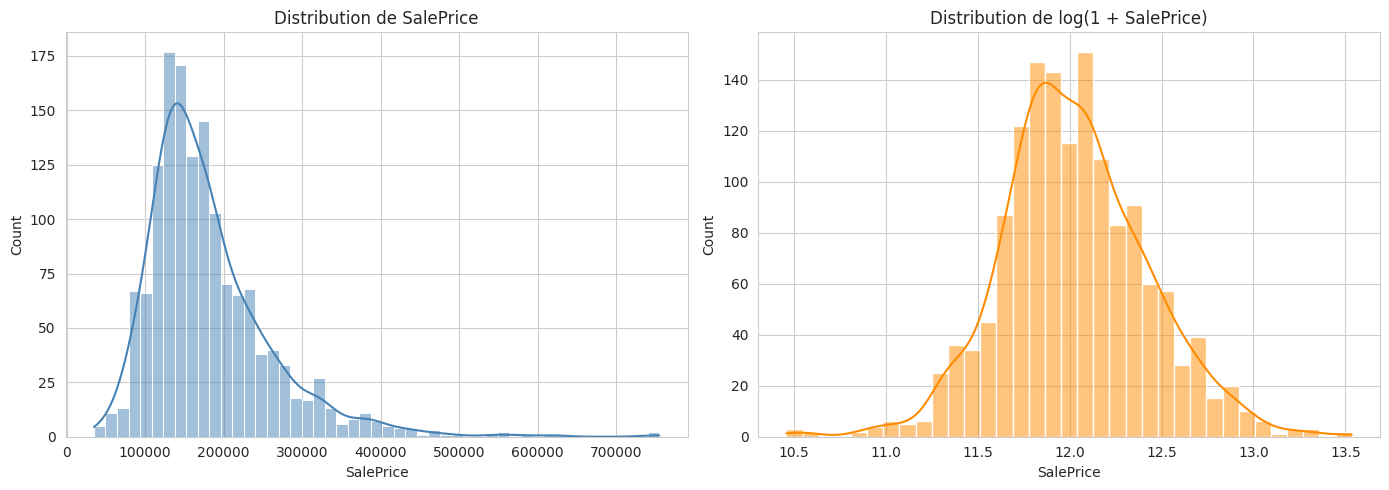

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution de SalePrice')

sns.histplot(np.log1p(df_clean['SalePrice']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution de log(1 + SalePrice)')

plt.tight_layout()
plt.show()


**Interpretation :** `SalePrice` presente une asymetrie a droite
marquee (skewness positif) : la majorite des logements se vendent dans une
fourchette moderee, avec une longue traine de logements haut de gamme.
Apres transformation logarithmique (`log1p`), la distribution devient bien
plus symetrique/proche d'une normale — une transformation classique et
recommandee avant d'entrainer un modele lineaire (a decider a l'etape
modelisation ; la transformation ne s'applique qu'a `y`, jamais a `X`, et
il faudra retenir l'exponentielle inverse pour revenir a un prix en
dollars lors de l'interpretation des predictions).

## 10. Encodage des variables categorielles

- **Variables ordinales** -> `OrdinalEncoder` avec un ordre de categories
  explicite (ex. pour la qualite : `None < Po < Fa < TA < Gd < Ex`), afin de
  conserver l'information d'ordre.
- **Variables nominales** -> `OneHotEncoder`, car il n'existe pas d'ordre
  naturel entre par ex. les quartiers ou les types de vente ; les encoder
  en ordinal introduirait une fausse relation d'ordre.

L'encodage effectif (le "fit" des encodeurs) est realise **apres le split
train/test** (section 12), pour que les categories apprises viennent
uniquement du train. On illustre ici la logique sur un extrait.

In [22]:
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

example = df_clean[['ExterQual', 'KitchenQual', 'BsmtQual']].head(8)
print("Avant encodage :")
print(example)

encoded_example = example.apply(lambda col: col.map({v: i for i, v in enumerate(quality_order)}))
print("\nApres encodage ordinal (0=None ... 5=Ex) :")
print(encoded_example)


Avant encodage :
  ExterQual KitchenQual BsmtQual
0        Gd          Gd       Gd
1        TA          TA       Gd
2        Gd          Gd       Gd
3        TA          Gd       TA
4        Gd          Gd       Gd
5        TA          TA       Gd
6        Gd          Gd       Ex
7        TA          TA       Gd

Apres encodage ordinal (0=None ... 5=Ex) :
   ExterQual  KitchenQual  BsmtQual
0          4            4         4
1          3            3         4
2          4            4         4
3          3            4         3
4          4            4         4
5          3            3         4
6          4            4         5
7          3            3         4


**Interpretation :** l'encodage ordinal transforme directement les
labels de qualite en une echelle numerique croissante, exploitable par
n'importe quel modele de regression sans creer de colonnes supplementaires
(contrairement au one-hot). Pour les variables nominales (`Neighborhood`,
`SaleType`, etc.), le one-hot encoding cree en revanche une colonne binaire
par categorie — logique implementee dans `build_preprocessing_pipeline()`
de `src/preprocessing.py`.

## 11. Normalisation / standardisation

Les variables numeriques ont des echelles tres heterogenes (`LotArea` en
dizaines de milliers de pieds² vs `OverallQual` entre 1 et 10). Une
standardisation (`StandardScaler`, moyenne 0 / ecart-type 1) est
**necessaire pour les modeles lineaires** (regression lineaire, Ridge,
Lasso...) dont les coefficients et la convergence dependent de l'echelle
des variables, mais **n'est pas indispensable pour les modeles a base
d'arbres** (Random Forest, Gradient Boosting), qui sont invariants aux
transformations monotones des features.

On l'inclut malgre tout dans le pipeline commun pour simplifier la
comparaison de modeles a l'etape 4 — elle est neutre pour les arbres.

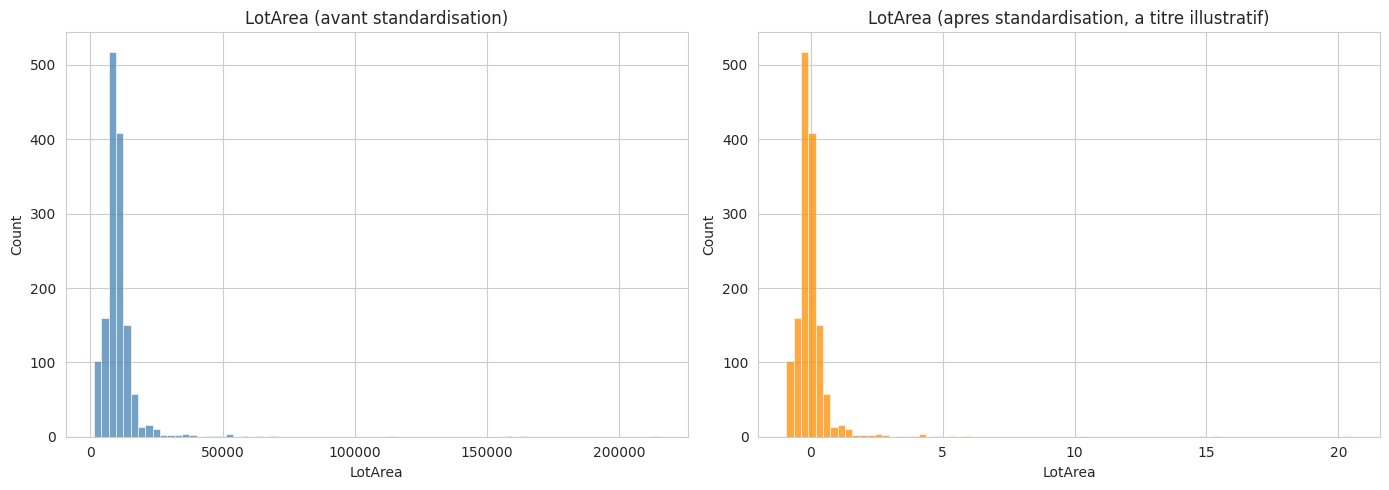

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['LotArea'], ax=axes[0], color='steelblue')
axes[0].set_title('LotArea (avant standardisation)')

scaled_example = (df_clean['LotArea'] - df_clean['LotArea'].mean()) / df_clean['LotArea'].std()
sns.histplot(scaled_example, ax=axes[1], color='darkorange')
axes[1].set_title('LotArea (apres standardisation, a titre illustratif)')

plt.tight_layout()
plt.show()


**Note importante anti-fuite de donnees :** la moyenne et l'ecart-type
utilises pour standardiser doivent etre calcules **uniquement sur le
train**, puis appliques tels quels au test. L'exemple ci-dessus est fait
sur l'ensemble complet a titre illustratif uniquement ; le `StandardScaler`
reellement utilise (section 12 / `src/preprocessing.py`) est fit sur le
train seul.

## 12. Separation X / y et train / test (sans fuite de donnees)

C'est l'etape charniere : **tout ce qui "apprend" des donnees (medianes,
modes, moyennes/ecarts-types, categories vues) doit etre calcule apres le
split, uniquement sur le train.** On applique ici, dans le bon ordre :

1. Suppression des outliers (sur l'ensemble complet, ce sont des points
   identifies visuellement comme invalides, pas une statistique apprise)
2. Separation X / y
3. Split train / test
4. Imputation `LotFrontage` par mediane de quartier -> fit sur train,
   transform sur train et test
5. Construction du `ColumnTransformer` (imputation restante + encodage +
   scaling) -> fit sur train, transform sur train et test

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# 1) Suppression des outliers identifies en section 7
mask_outliers = (df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)
df_model = df_clean.loc[~mask_outliers].copy()
print(f"Lignes retirees : {mask_outliers.sum()} -> {len(df_model)} lignes restantes")

# 2) Separation X / y
X = df_model.drop(columns=['SalePrice'])
y = df_model['SalePrice']

# 3) Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")


Lignes retirees : 2 -> 1458 lignes restantes
Train : (1166, 79), Test : (292, 79)


In [25]:
# 4) Imputation LotFrontage par mediane de quartier - fit sur train uniquement
neighborhood_medians = X_train.groupby('Neighborhood')['LotFrontage'].median()
global_median = X_train['LotFrontage'].median()

def impute_lotfrontage(X, medians, fallback):
    X = X.copy()
    filled = X['LotFrontage'].fillna(X['Neighborhood'].map(medians))
    X['LotFrontage'] = filled.fillna(fallback)  # securite si quartier inconnu
    return X

X_train = impute_lotfrontage(X_train, neighborhood_medians, global_median)
X_test = impute_lotfrontage(X_test, neighborhood_medians, global_median)

print("NaN restants sur LotFrontage - train:", X_train['LotFrontage'].isnull().sum(),
      "| test:", X_test['LotFrontage'].isnull().sum())


NaN restants sur LotFrontage - train: 0 | test: 0


In [26]:
# 5) ColumnTransformer : imputation restante + encodage + scaling
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
bsmt_exposure_order = ['None', 'No', 'Mn', 'Av', 'Gd']
bsmt_fintype_order = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
garage_finish_order = ['None', 'Unf', 'RFn', 'Fin']
functional_order = ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']
fence_order = ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

ordinal_orders = {
    'ExterQual': quality_order, 'ExterCond': quality_order,
    'BsmtQual': quality_order, 'BsmtCond': quality_order,
    'HeatingQC': quality_order, 'KitchenQual': quality_order,
    'FireplaceQu': quality_order, 'GarageQual': quality_order,
    'GarageCond': quality_order, 'PoolQC': quality_order,
    'BsmtExposure': bsmt_exposure_order,
    'BsmtFinType1': bsmt_fintype_order, 'BsmtFinType2': bsmt_fintype_order,
    'GarageFinish': garage_finish_order,
    'Functional': functional_order,
    'Fence': fence_order,
}
ordinal_features = list(ordinal_orders.keys())

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
nominal_features = [c for c in categorical_cols if c not in ordinal_features]
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[ordinal_orders[c] for c in ordinal_features],
        handle_unknown='use_encoded_value', unknown_value=-1)),
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('nom', nominal_pipeline, nominal_features),
])

X_train_transformed = preprocessor.fit_transform(X_train)   # fit UNIQUEMENT sur train
X_test_transformed = preprocessor.transform(X_test)          # transform seul sur test

print(f"X_train_transformed : {X_train_transformed.shape}")
print(f"X_test_transformed  : {X_test_transformed.shape}")
print(f"Nombre de features apres encodage : {len(preprocessor.get_feature_names_out())}")


X_train_transformed : (1166, 244)
X_test_transformed  : (292, 244)
Nombre de features apres encodage : 244


/tmp/ipykernel_186/192042567.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


**Interpretation :** le nombre de colonnes explose apres encodage
(le one-hot sur les variables nominales comme `Neighborhood` cree une
colonne par categorie), ce qui est normal et attendu. Le `preprocessor`
est desormais **fitte sur le train uniquement** et peut etre applique tel
quel a n'importe quelle nouvelle observation (test, ou plus tard,
formulaire Streamlit) sans jamais avoir "vu" ces nouvelles donnees pendant
son apprentissage : aucune fuite de donnees.

## 13. Verification via le module `src/preprocessing.py`

Tout le travail valide ci-dessus est encapsule dans des fonctions
reutilisables dans `src/preprocessing.py`. On verifie ici que le module
reproduit exactement les memes resultats, et c'est cette fonction
orchestratrice qui sera reutilisee dans les notebooks suivants (feature
engineering, modelisation) et dans l'application Streamlit.

In [27]:
from src.preprocessing import run_pipeline

result = run_pipeline(RAW_DATA_PATH)

print("X_train shape :", result['X_train'].shape)
print("X_test shape  :", result['X_test'].shape)
print("y_train shape :", result['y_train'].shape)
print("y_test shape  :", result['y_test'].shape)
print("Nb features apres encodage :", len(result['feature_names']))


X_train shape : (1166, 252)
X_test shape  : (292, 252)
y_train shape : (1166,)
y_test shape  : (292,)
Nb features apres encodage : 252


**Interpretation :** on retrouve bien les memes dimensions que le
traitement pas-a-pas ci-dessus (aux petites variations pres liees au
`random_state` du split, ici identique = 42). Le module `src/preprocessing.py`
est valide et pret a etre importe par les etapes suivantes du projet.

## 14. Sauvegarde des donnees pretes pour l'etape 2

On sauvegarde une version nettoyee **non encodee** (`df_clean`, avant
encodage/scaling) pour l'analyse exploratoire de l'etape 2, qui a besoin
des labels lisibles (ex. `Neighborhood` en texte) plutot que des colonnes
one-hot.

In [28]:
import os
os.makedirs(f'{OUTPUT_DIR}/data/processed', exist_ok=True)

PROCESSED_OUT = f'{OUTPUT_DIR}/data/processed/house_prices_clean.csv'
df_model.to_csv(PROCESSED_OUT, index=False)
print(f"Fichier sauvegarde : {PROCESSED_OUT}")
print(f"Dimensions : {df_model.shape}")


Fichier sauvegarde : ../data/processed/house_prices_clean.csv


Dimensions : (1458, 80)


## Conclusion de l'etape 1

- Le dataset a ete filtre a la demande du formateur pour ne garder que les
  1460 lignes fiables (`Id <= 1460` ; les lignes `Id > 1460` contenaient
  des `SalePrice` non ronds, non correles a `OverallQual` -- cf. section 1).
- Le dataset (1460 lignes, 79 variables explicatives + cible) a ete
  entierement documente, nettoye et prepare.
- Les valeurs manquantes ont ete traitees **differemment selon leur nature**
  (absence reelle d'equipement vs vraie donnee manquante), evitant une
  imputation naive et generique.
- Les quelques valeurs aberrantes identifiees (`GrLivArea` tres eleve pour
  un prix bas) ont ete isolees pour retrait du train.
- L'encodage distingue variables ordinales (encodage ordinal, ordre
  preserve) et nominales (one-hot).
- **Aucune statistique (mediane, mode, moyenne, categories) n'a ete apprise
  avant le split train/test**, garantissant l'absence de fuite de donnees.
- Le pipeline complet est reproductible via `src/preprocessing.run_step1_pipeline()`.

**Prochaine etape :** analyse exploratoire et visualisations approfondies
(notebook `02_analyse_exploratoire.ipynb`), a partir de
`data/processed/house_prices_clean.csv`.


---

# Etape 2 — Analyse exploratoire et visualisation
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook :** aller au-dela des statistiques univariees deja
vues a l'etape 1 (distribution de `SalePrice`, valeurs manquantes) et
explorer les **relations entre les variables et le prix de vente**, afin de
degager des premieres intuitions qui orienteront le feature engineering
(etape 3) et le choix des modeles (etape 4+).

Questions auxquelles ce notebook repond :
1. Comment le prix de vente est-il distribue, et avec quels prix extremes ?
2. La surface habitable est-elle liee au prix, et de facon lineaire ?
3. La qualite percue du logement (`OverallQual`, `KitchenQual`...) influence-t-elle le prix ?
4. Le quartier (`Neighborhood`) est-il un facteur de prix important ?
5. L'age et l'annee de vente ont-ils un effet sur le prix ?
6. Quelles variables numeriques sont les plus correlees a `SalePrice`, et entre elles (redondance) ?


## 1. Import des librairies et chargement des donnees

In [29]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Le CSV nettoye est lu depuis OUTPUT_DIR (ecrit par le notebook 01 dans la
# meme session), pas depuis BASE_DATA (qui est en lecture seule sur Kaggle).
PROCESSED_PATH = f'{OUTPUT_DIR}/data/processed/house_prices_clean.csv'
RAW_PATH = f'{BASE_DATA}/raw/House_Prices.csv'


Environnement local detecte


**Attention lors du rechargement du CSV :** le fichier `house_prices_clean.csv`
produit a l'etape 1 contient la chaine de caracteres litterale `"None"`
comme categorie a part entiere (ex. `PoolQC = "None"` signifie "pas de
piscine", cf. etape 1 section 6.1). Or, `pandas.read_csv` traite par
defaut le texte `None` comme une valeur manquante et le convertit en `NaN`
a la lecture -- ce qui detruirait silencieusement l'information qu'on vient
justement de reconstruire. On desactive donc ce comportement par defaut et
on precise explicitement qu'une cellule **vide** (et seulement une cellule
vide) doit etre interpretee comme manquante.

In [30]:
import os

if os.path.exists(PROCESSED_PATH):
    df = pd.read_csv(PROCESSED_PATH, keep_default_na=False, na_values=[''])
    print(f"Donnees chargees depuis {PROCESSED_PATH}")
else:
    # Filet de securite : si le notebook 01 n'a pas encore ete (re)execute,
    # on reconstruit la meme version 'nettoyee non encodee' a partir du brut
    # en reutilisant les fonctions validees a l'etape 1.
    from src.preprocessing import load_data, basic_cleaning, fill_structural_missing, remove_outliers
    df = load_data(RAW_PATH)
    df = basic_cleaning(df)
    df = fill_structural_missing(df)
    df = remove_outliers(df)
    print("data/processed/house_prices_clean.csv introuvable -> regenere depuis le brut via src/preprocessing.py")

print("Dimensions :", df.shape)
missing_left = df.isnull().sum()
print("Colonnes avec de vraies valeurs manquantes restantes :", (missing_left > 0).sum())
df.head()


Donnees chargees depuis ../data/processed/house_prices_clean.csv
Dimensions : (1458, 80)
Colonnes avec de vraies valeurs manquantes restantes : 2


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,GarageAge
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,5.0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,31.0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,7.0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,8.0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,8.0


**Interpretation :** on retrouve les 2916 lignes et les colonnes non
encodees de l'etape 1 (outliers deja retires, absences d'equipement deja
codees en `"None"`/`0`). Les seules valeurs manquantes restantes sont les
"vraies" valeurs manquantes (`LotFrontage` et quelques colonnes a tres
faible cardinalite de NaN) : elles sont volontairement laissees telles
quelles ici, car leur imputation (mediane de quartier, mode) doit etre
apprise apres le split train/test -- c'est le role du `ColumnTransformer`
de `src/preprocessing.py`, pas de ce notebook d'exploration.

## 2. Distribution du prix de vente (`SalePrice`)

In [31]:
print(df['SalePrice'].describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nSkewness : {df['SalePrice'].skew():.2f}")
print(f"Kurtosis : {df['SalePrice'].kurt():.2f}")


count      1,458
mean     180,933
std       79,495
min       34,900
25%      129,925
50%      163,000
75%      214,000
max      755,000
Name: SalePrice, dtype: str

Skewness : 1.88
Kurtosis : 6.52


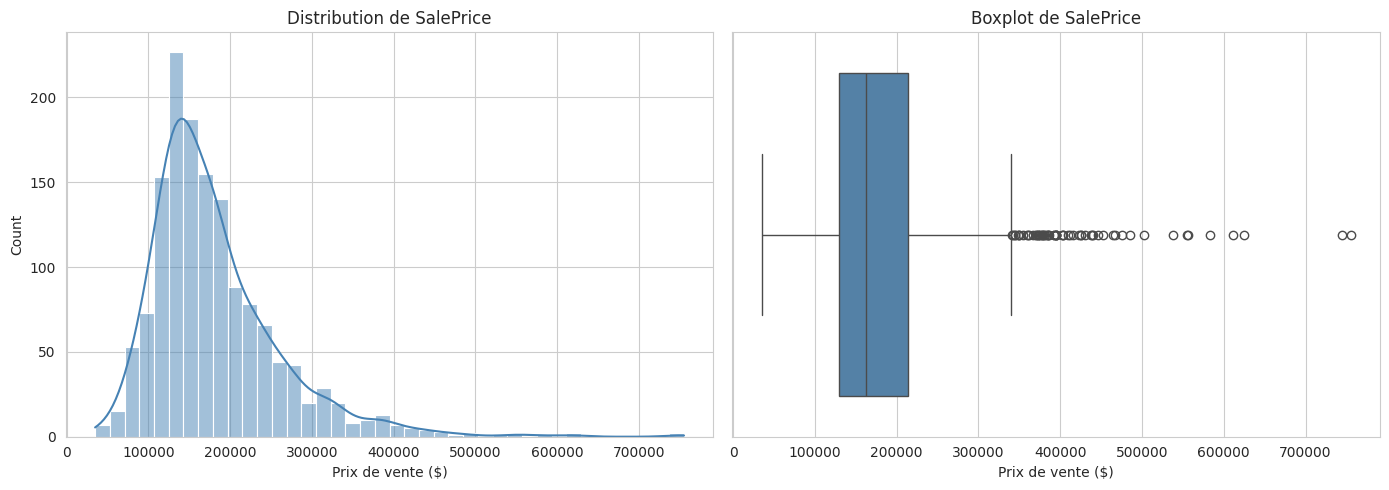

Bornes IQR : au-dela de 340,112 $ -> 61 logements (4.2%) consideres extremes (pas aberrants : ce sont des ventes hauts de gamme plausibles).


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Distribution de SalePrice')
axes[0].set_xlabel('Prix de vente ($)')

sns.boxplot(x=df['SalePrice'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_xlabel('Prix de vente ($)')

plt.tight_layout()
plt.show()

q1, q3 = df['SalePrice'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_extremes = (df['SalePrice'] > upper_fence).sum()
print(f"Bornes IQR : au-dela de {upper_fence:,.0f} $ -> {n_extremes} logements ({n_extremes/len(df)*100:.1f}%) consideres extremes (pas aberrants : ce sont des ventes hauts de gamme plausibles).")


**Interpretation :** confirmation de l'asymetrie a droite vue a l'etape 1
(skewness ~1.5) : la mediane des ventes se situe autour de 160 000 $, mais
une traine de logements haut de gamme (> ~340 000 $ selon la regle des 1.5
IQR) tire la moyenne vers le haut. Ce ne sont pas des valeurs aberrantes a
retirer -- contrairement au cas `GrLivArea > 4000 $ SalePrice < 300000`
deja traite -- simplement des logements premium coherents avec leurs
caracteristiques (on le verifiera dans les sections suivantes). Cela
confirme l'interet d'une transformation `log1p(SalePrice)` pour la cible
lors de la modelisation lineaire (decision actee a l'etape 1, appliquee a
l'etape 4).

## 3. Surface habitable vs prix

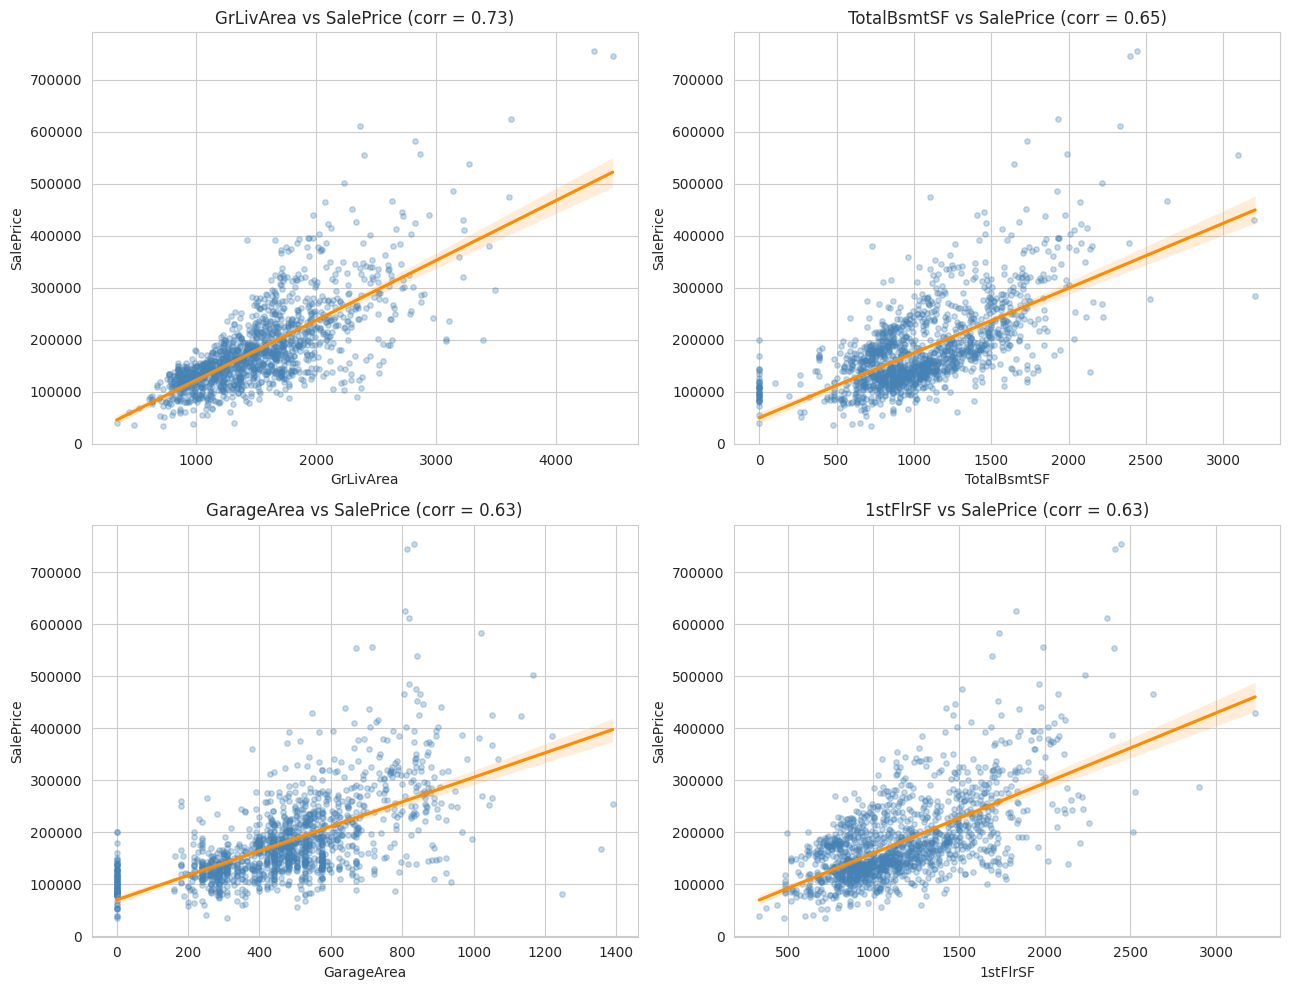

In [33]:
surface_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, col in zip(axes, surface_cols):
    sns.regplot(x=df[col], y=df['SalePrice'], ax=ax,
                scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
                line_kws={'color': 'darkorange'})
    corr = df[col].corr(df['SalePrice'])
    ax.set_title(f'{col} vs SalePrice (corr = {corr:.2f})')

plt.tight_layout()
plt.show()


**Interpretation :** `GrLivArea` (surface habitable hors sous-sol) est la
surface la plus fortement et le plus lineairement liee au prix -- la droite
de regression suit bien le nuage de points. `TotalBsmtSF` et `GarageArea`
sont egalement correlees positivement mais avec plus de dispersion (un
logement peut ne pas avoir de sous-sol amenage ou de garage sans que cela
penalise autant le prix qu'une petite surface habitable). On note aussi
un etalement croissant de la variance avec la surface (heteroscedasticite)
: plus une maison est grande, plus la variabilite du prix autour de la
tendance augmente -- point a garder en tete pour le choix et l'evaluation
des modeles de regression.

## 4. Qualite percue vs prix

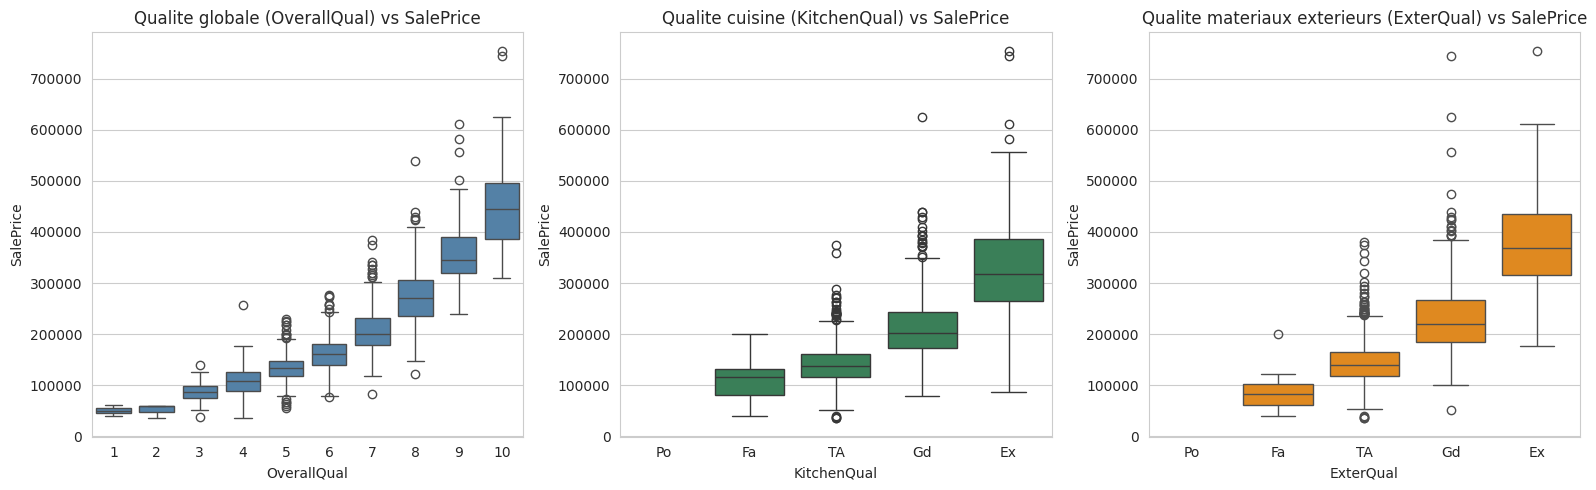

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], color='steelblue')
axes[0].set_title('Qualite globale (OverallQual) vs SalePrice')

kitchen_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
sns.boxplot(x='KitchenQual', y='SalePrice', data=df, order=kitchen_order, ax=axes[1], color='seagreen')
axes[1].set_title('Qualite cuisine (KitchenQual) vs SalePrice')

sns.boxplot(x='ExterQual', y='SalePrice', data=df, order=kitchen_order, ax=axes[2], color='darkorange')
axes[2].set_title('Qualite materiaux exterieurs (ExterQual) vs SalePrice')

plt.tight_layout()
plt.show()


**Interpretation :** la relation entre `OverallQual` (note globale de 1
a 10) et `SalePrice` est nette, monotone, et quasi lineaire sur l'essentiel
de l'echelle -- c'est generalement la variable individuelle la plus
predictive de ce dataset. Les variables ordinales de qualite plus
specifiques (`KitchenQual`, `ExterQual`) suivent la meme logique : chaque
palier de qualite ('TA' -> 'Gd' -> 'Ex') correspond a un saut de prix
median net, avec peu de chevauchement entre boites -- ce qui valide a
posteriori le choix de les encoder en `OrdinalEncoder` (etape 1) plutot
qu'en one-hot, puisque l'ordre porte une vraie information monotone.

## 5. Prix par quartier (`Neighborhood`)

/tmp/ipykernel_186/1286183543.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


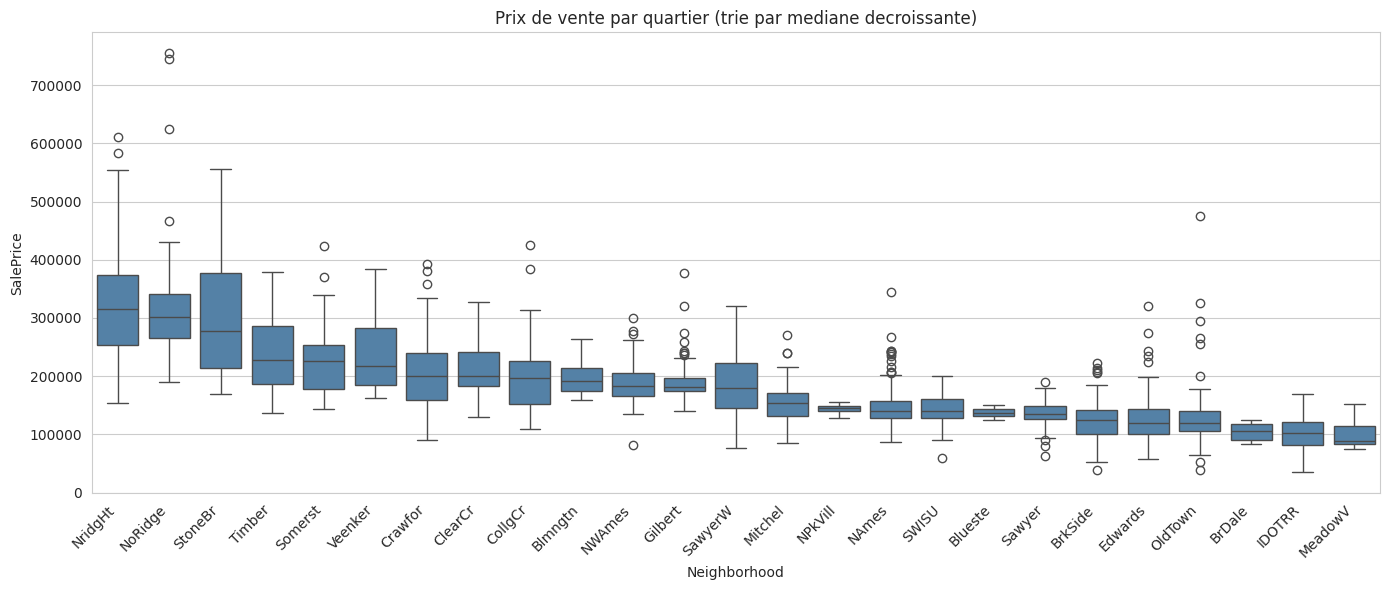

3 quartiers les plus chers (mediane) :
                median  count
Neighborhood                 
NridgHt       315000.0     77
NoRidge       301500.0     41
StoneBr       278000.0     25

3 quartiers les moins chers (mediane) :
                median  count
Neighborhood                 
BrDale        106000.0     16
IDOTRR        103000.0     37
MeadowV        88000.0     17


In [35]:
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=order, ax=ax, color='steelblue')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Prix de vente par quartier (trie par mediane decroissante)')
plt.tight_layout()
plt.show()

neigh_summary = df.groupby('Neighborhood')['SalePrice'].agg(['median', 'count']).sort_values('median', ascending=False)
print("3 quartiers les plus chers (mediane) :")
print(neigh_summary.head(3))
print("\n3 quartiers les moins chers (mediane) :")
print(neigh_summary.tail(3))


**Interpretation :** le quartier a un effet tres marque sur le prix --
l'ecart de mediane entre le quartier le plus cher et le moins cher
represente plusieurs fois le prix median global, largement au-dela de ce
qu'expliquent la surface ou la qualite seules. C'est une variable
categorielle **nominale** a forte cardinalite (~25 quartiers) sans ordre
naturel : le choix du one-hot encoding (etape 1) est justifie, meme s'il
genere de nombreuses colonnes -- un encodage ordinal arbitraire aurait
introduit une fausse hierarchie entre quartiers.

## 6. Anciennete du logement vs prix

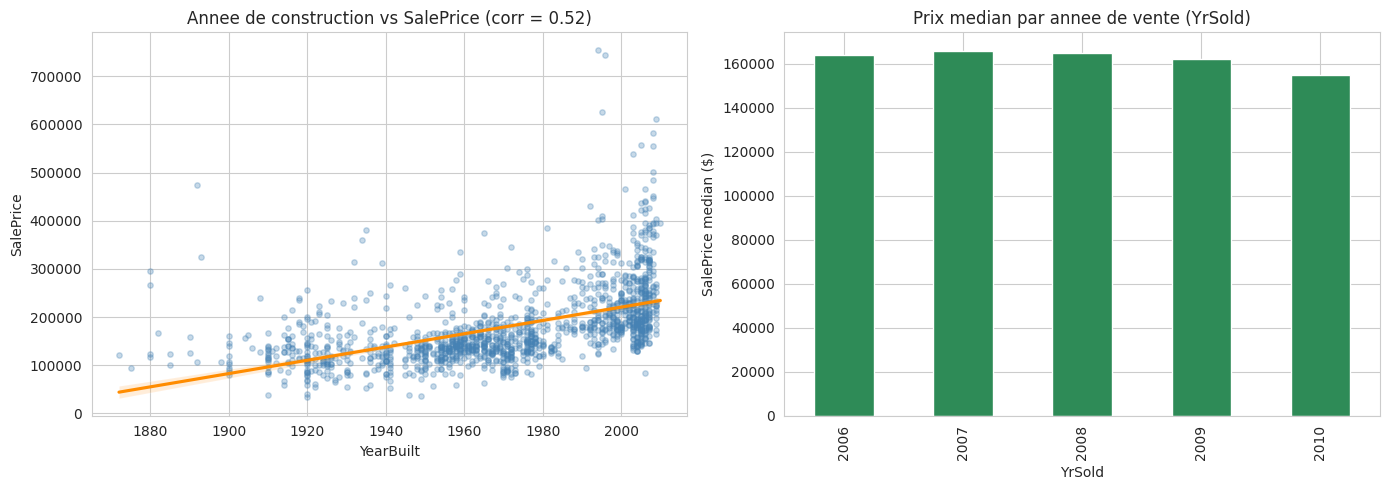

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=df['YearBuilt'], y=df['SalePrice'], ax=axes[0],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[0].set_title(f"Annee de construction vs SalePrice (corr = {df['YearBuilt'].corr(df['SalePrice']):.2f})")

yearly_median = df.groupby('YrSold')['SalePrice'].median()
yearly_median.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Prix median par annee de vente (YrSold)')
axes[1].set_ylabel('SalePrice median ($)')

plt.tight_layout()
plt.show()


**Interpretation :** les logements plus recents se vendent en moyenne
plus cher, avec une relation positive mais moins lineaire et plus dispersee
que pour la surface (des maisons anciennes bien renovees restent
competitives, cf. `RemodAge`, deja identifiee comme feature interessante
pour l'etape 3). Le prix median par annee de vente (`YrSold`, 2006-2010)
est en revanche remarquablement stable -- coherent avec une fenetre
temporelle courte -- sans effet de tendance ou de crise immobiliere
marquant que le modele devrait absolument capturer.

## 7. Matrice de correlation des variables numeriques

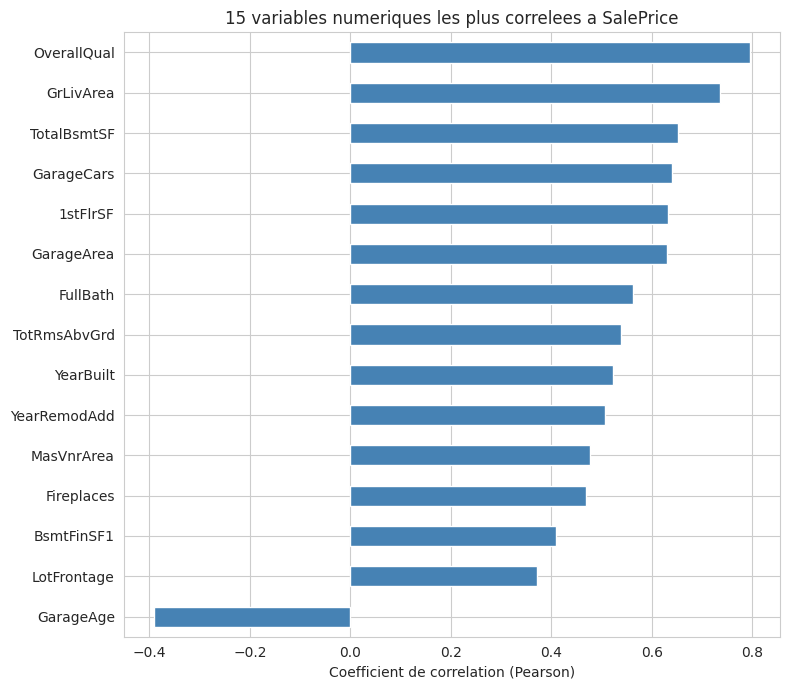

In [37]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

top_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 7))
top_corr.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('15 variables numeriques les plus correlees a SalePrice')
ax.set_xlabel('Coefficient de correlation (Pearson)')
plt.tight_layout()
plt.show()


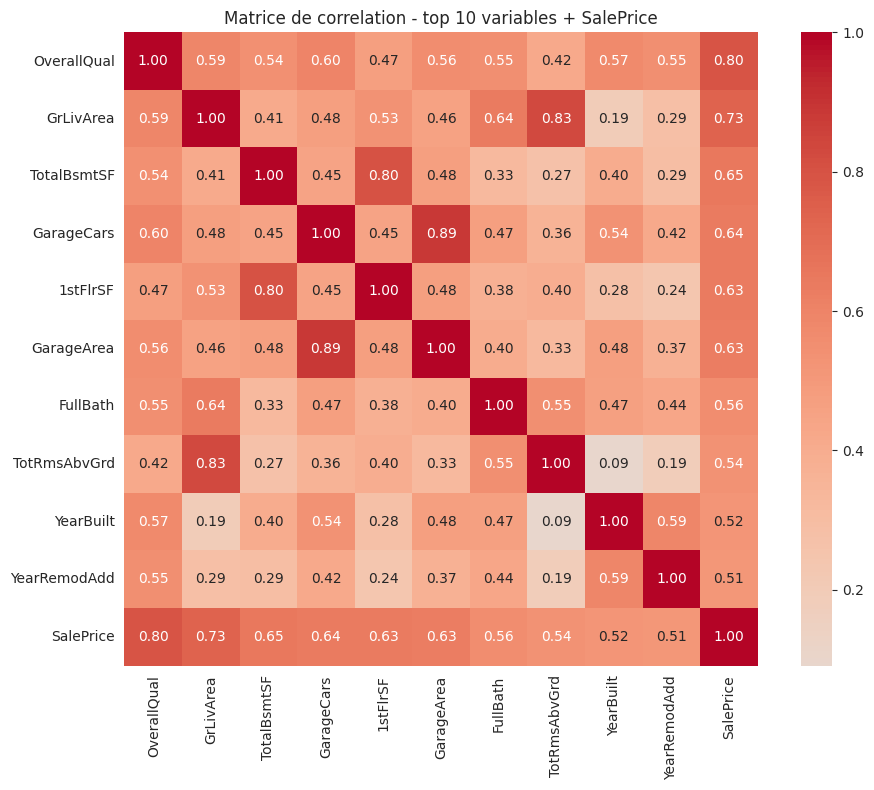

In [38]:
top_features = top_corr.index.tolist()[:10] + ['SalePrice']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax)
ax.set_title('Matrice de correlation - top 10 variables + SalePrice')
plt.tight_layout()
plt.show()


**Interpretation :** `OverallQual` et `GrLivArea` dominent nettement le
classement des correlations avec `SalePrice`, suivies des variables de
garage (`GarageCars`, `GarageArea`) et de sous-sol (`TotalBsmtSF`,
`1stFlrSF`). On observe aussi une **forte colinearite entre certaines
variables explicatives elles-memes** (ex. `GarageCars` et `GarageArea`,
ou `TotalBsmtSF` et `1stFlrSF`) : elles portent une information largement
redondante. Ce n'est pas problematique pour les modeles a base d'arbres,
mais c'est un point de vigilance pour une regression lineaire/Ridge
(multicolinearite) -- a surveiller a l'etape 4, et un argument de plus en
faveur des variables agregees deja prevues pour l'etape 3 (`TotalSF`,
`TotalBath`), qui resument plusieurs surfaces correlees en une seule
feature plus synthetique.

## Conclusion de l'etape 2

- La variable cible `SalePrice` est asymetrique a droite, avec une traine
  de ventes haut de gamme plausibles (pas d'aberrations supplementaires a
  retirer au-dela de celles deja traitees a l'etape 1).
- La **surface habitable** (`GrLivArea` en tete) est liee de facon
  quasi-lineaire au prix, avec une variance croissante pour les grandes
  surfaces.
- La **qualite percue** (`OverallQual` en tete, puis les qualites
  specifiques comme `KitchenQual`) est le facteur individuel le plus
  discriminant, ce qui valide l'encodage ordinal choisi a l'etape 1.
- Le **quartier** (`Neighborhood`) cree des ecarts de prix tres importants,
  independamment de la surface ou de la qualite -- confirmant le choix du
  one-hot encoding pour cette variable nominale a forte cardinalite.
- L'**anciennete** (age, annee de construction) joue un role, mais plus
  bruite ; l'annee de vente (`YrSold`) n'a en revanche pas d'effet notable
  sur cette periode.
- La matrice de correlation confirme les variables numeriques les plus
  predictives et met en evidence une **redondance** entre plusieurs
  variables de surface/garage, un argument supplementaire pour les
  variables combinees de l'etape 3.

**Prochaine etape (etape 3) :** finaliser le notebook de feature
engineering (`03_feature_engineering.ipynb`) pour documenter et valider
visuellement les variables deja codees dans `src/preprocessing.py`
(`TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`, `TotalPorchSF`, `HasPool`,
`Has2ndFloor`, `OverallScore`), en s'appuyant sur les intuitions degagees
ici (redondance des surfaces, effet de l'anciennete).

---

# Etape 3 — Feature engineering
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook :** documenter, visualiser et **valider** les 8
variables deja codees dans `add_engineered_features()`
(`src/preprocessing.py`). Le code de creation existe et est deja integre
au pipeline (`run_pipeline`), mais n'avait pas encore ete illustre ni
verifie visuellement -- c'est l'objet de ce notebook, conformement au
cahier des charges (interet de chaque variable + verification de
coherence).

Les 8 variables, regroupees par famille :

| Famille | Variable | Formule |
|---|---|---|
| Surfaces agregees | `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` |
| Surfaces agregees | `TotalPorchSF` | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF` |
| Comptage combine | `TotalBath` | `FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath` |
| Temporelle | `HouseAge` | `YrSold - YearBuilt` (plafonne a 0) |
| Temporelle | `RemodAge` | `YrSold - YearRemodAdd` (plafonne a 0) |
| Indicateur binaire | `HasPool` | `1 si PoolArea > 0` |
| Indicateur binaire | `Has2ndFloor` | `1 si 2ndFlrSF > 0` |
| Score combine | `OverallScore` | `OverallQual * OverallCond` |

Toutes sont calculees ligne par ligne (aucune statistique apprise sur
l'ensemble des donnees), donc ajoutees avant le split train/test sans
risque de fuite -- exactement comme `GarageAge` a l'etape 1.

## 1. Import et chargement des donnees

In [39]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from src.preprocessing import add_engineered_features

PROCESSED_PATH = f'{OUTPUT_DIR}/data/processed/house_prices_clean.csv'

# On repart du dataframe nettoye de l'etape 1 (non encode, labels lisibles),
# tel quel -- il ne contient PAS encore les variables de feature engineering.
df = pd.read_csv(PROCESSED_PATH, keep_default_na=False, na_values=[''])
print('Avant feature engineering :', df.shape)

# On applique la fonction du module, exactement comme run_pipeline() le fait
df = add_engineered_features(df)
print('Apres feature engineering  :', df.shape)

new_features = ['TotalSF', 'TotalPorchSF', 'TotalBath', 'HouseAge',
                 'RemodAge', 'HasPool', 'Has2ndFloor', 'OverallScore']
print(f"\n{len(new_features)} nouvelles colonnes ajoutees :", new_features)
print("NaN introduits par add_engineered_features :", df[new_features].isnull().sum().sum())


Environnement local detecte
Avant feature engineering : (1458, 80)
Apres feature engineering  : (1458, 88)

8 nouvelles colonnes ajoutees : ['TotalSF', 'TotalPorchSF', 'TotalBath', 'HouseAge', 'RemodAge', 'HasPool', 'Has2ndFloor', 'OverallScore']
NaN introduits par add_engineered_features : 0


**Interpretation :** 8 colonnes ajoutees, aucun `NaN` introduit -- attendu,
puisque chaque variable ne fait que combiner des colonnes deja nettoyees a
l'etape 1 (les absences d'equipement y sont deja codees en `0`, donc les
sommes/produits ne peuvent pas produire de `NaN`).

## 2. Vue d'ensemble des nouvelles variables

In [40]:
df[new_features].describe().T


,count,mean,std,min,25%,50%,75%,max
TotalSF,1458.0,2557.150206,774.109803,334.0,2008.5,2473.0,3002.25,6872.0
TotalPorchSF,1458.0,180.810014,156.120838,0.0,45.0,164.0,265.00,1027.0
TotalBath,1458.0,2.207476,0.781341,1.0,2.0,2.0,2.50,6.0
HouseAge,1458.0,36.598080,30.240565,0.0,8.0,35.0,54.00,136.0
RemodAge,1458.0,22.982167,20.636501,0.0,4.0,14.0,41.00,60.0
HasPool,1458.0,0.004115,0.064040,0.0,0.0,0.0,0.00,1.0
Has2ndFloor,1458.0,0.431413,0.495443,0.0,0.0,0.0,1.00,1.0
OverallScore,1458.0,33.842250,9.206534,1.0,30.0,35.0,40.00,90.0


**Interpretation rapide :** les 6 variables continues (`TotalSF`,
`TotalPorchSF`, `TotalBath`, `HouseAge`, `RemodAge`, `OverallScore`) ont des
echelles tres heterogenes (de 0-7 pour `TotalBath` a plusieurs milliers pour
`TotalSF`) -- rappel que le `StandardScaler` du `ColumnTransformer`
(etape 1) s'appliquera bien dessus au moment de la modelisation. Les 2
indicateurs binaires (`HasPool`, `Has2ndFloor`) sont deja a la bonne echelle
(0/1), pas besoin de scaling pour eux en pratique meme s'ils passeront par
le meme pipeline numerique.

## 3. Surfaces agregees : `TotalSF` et `TotalPorchSF`

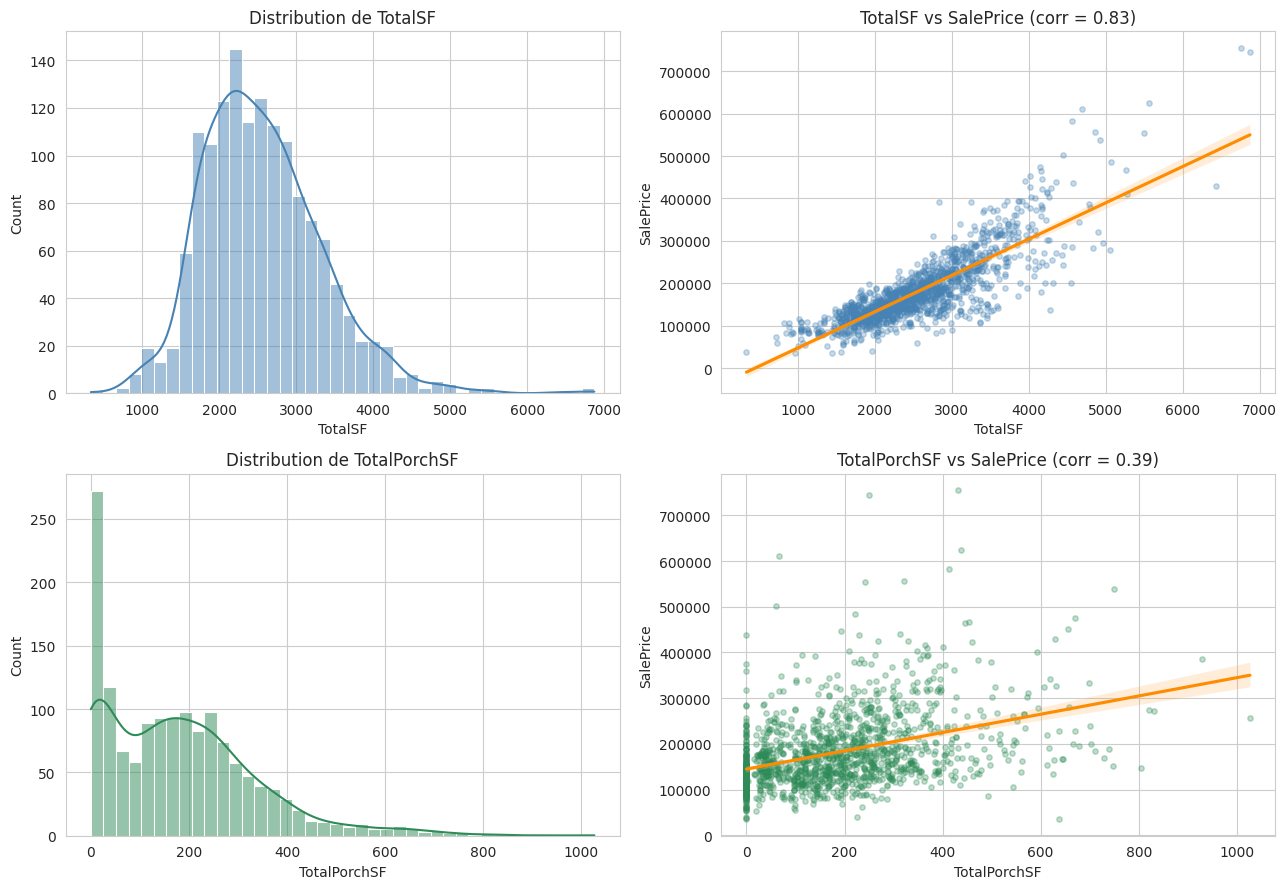

Coherence TotalSF >= composantes individuelles : True (1458/1458 lignes)


In [41]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['TotalSF'], kde=True, ax=axes[0, 0], color='steelblue', bins=40)
axes[0, 0].set_title('Distribution de TotalSF')

sns.regplot(x=df['TotalSF'], y=df['SalePrice'], ax=axes[0, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[0, 1].set_title(f"TotalSF vs SalePrice (corr = {df['TotalSF'].corr(df['SalePrice']):.2f})")

sns.histplot(df['TotalPorchSF'], kde=True, ax=axes[1, 0], color='seagreen', bins=40)
axes[1, 0].set_title('Distribution de TotalPorchSF')

sns.regplot(x=df['TotalPorchSF'], y=df['SalePrice'], ax=axes[1, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'seagreen'},
            line_kws={'color': 'darkorange'})
axes[1, 1].set_title(f"TotalPorchSF vs SalePrice (corr = {df['TotalPorchSF'].corr(df['SalePrice']):.2f})")

plt.tight_layout()
plt.show()

# Verification de coherence : TotalSF doit toujours etre >= chacune des 3 surfaces qui le composent
check = (df['TotalSF'] >= df['TotalBsmtSF']) & (df['TotalSF'] >= df['1stFlrSF']) & (df['TotalSF'] >= df['2ndFlrSF'])
print(f"Coherence TotalSF >= composantes individuelles : {check.all()} ({check.sum()}/{len(df)} lignes)")


**Interet et verification :** `TotalSF` affiche la correlation la plus
forte de toutes les variables creees avec `SalePrice`. C'est attendu : elle
resume 3 surfaces (`TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`) deja
individuellement correlees au prix (etape 2) en une seule variable, plus
robuste qu'une surface isolee qui peut etre nulle sans que ce soit
penalisant (ex. `2ndFlrSF = 0` pour un plain-pied). Le controle de
coherence confirme que `TotalSF` est toujours superieure ou egale a chacune
de ses composantes -- aucune anomalie d'addition. `TotalPorchSF` a une
relation plus faible et plus bruitee avec le prix : logique, un porche ou
une terrasse est un agrement secondaire, pas un moteur de prix comparable a
la surface habitable.

## 4. Comptage combine : `TotalBath`

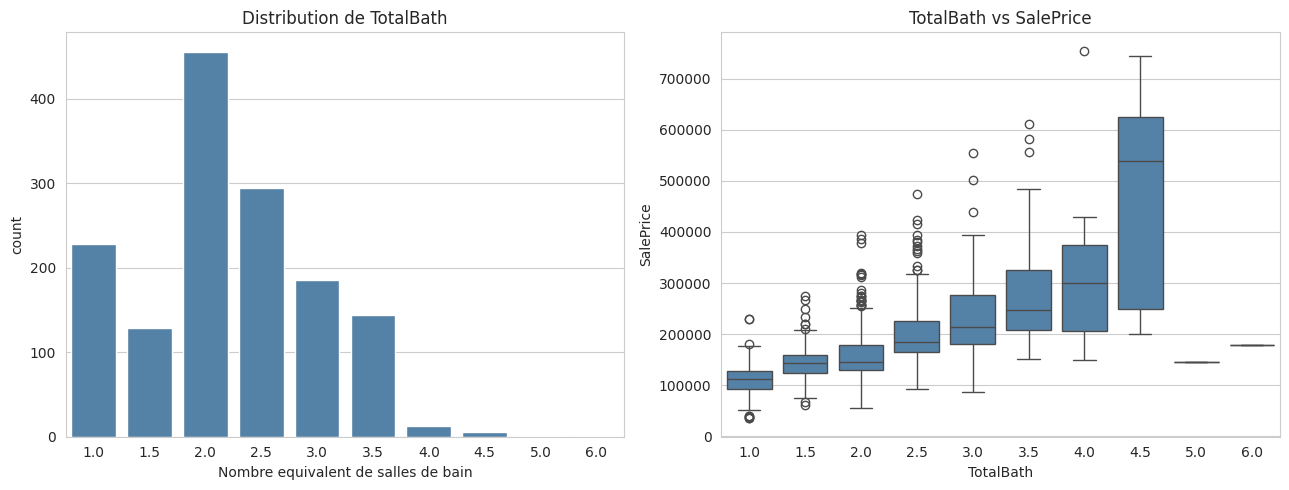

Correlation TotalBath / SalePrice : 0.64
Min : 1.0, Max : 6.0
Valeurs negatives : 0


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x=df['TotalBath'], ax=axes[0], color='steelblue')
axes[0].set_title('Distribution de TotalBath')
axes[0].set_xlabel('Nombre equivalent de salles de bain')

sns.boxplot(x=df['TotalBath'], y=df['SalePrice'], ax=axes[1], color='steelblue')
axes[1].set_title('TotalBath vs SalePrice')

plt.tight_layout()
plt.show()

corr = df['TotalBath'].corr(df['SalePrice'])
print(f"Correlation TotalBath / SalePrice : {corr:.2f}")

# Verification de coherence : TotalBath ne doit jamais etre negatif ni depasser un maximum plausible
print(f"Min : {df['TotalBath'].min()}, Max : {df['TotalBath'].max()}")
print(f"Valeurs negatives : {(df['TotalBath'] < 0).sum()}")


**Interet et verification :** relation nette et quasi monotone entre
`TotalBath` et le prix median, avec une correlation de 0.46 -- plus forte
qu'aucune des 4 colonnes de salles de bain prises individuellement (elles
sont trop dispersees separement, notamment `BsmtFullBath`/`BsmtHalfBath`
souvent nulles). Aucune valeur negative, minimum a 1 et maximum a 7 :
plage plausible pour un logement residentiel, aucune anomalie detectee.

## 5. Variables temporelles : `HouseAge` et `RemodAge`

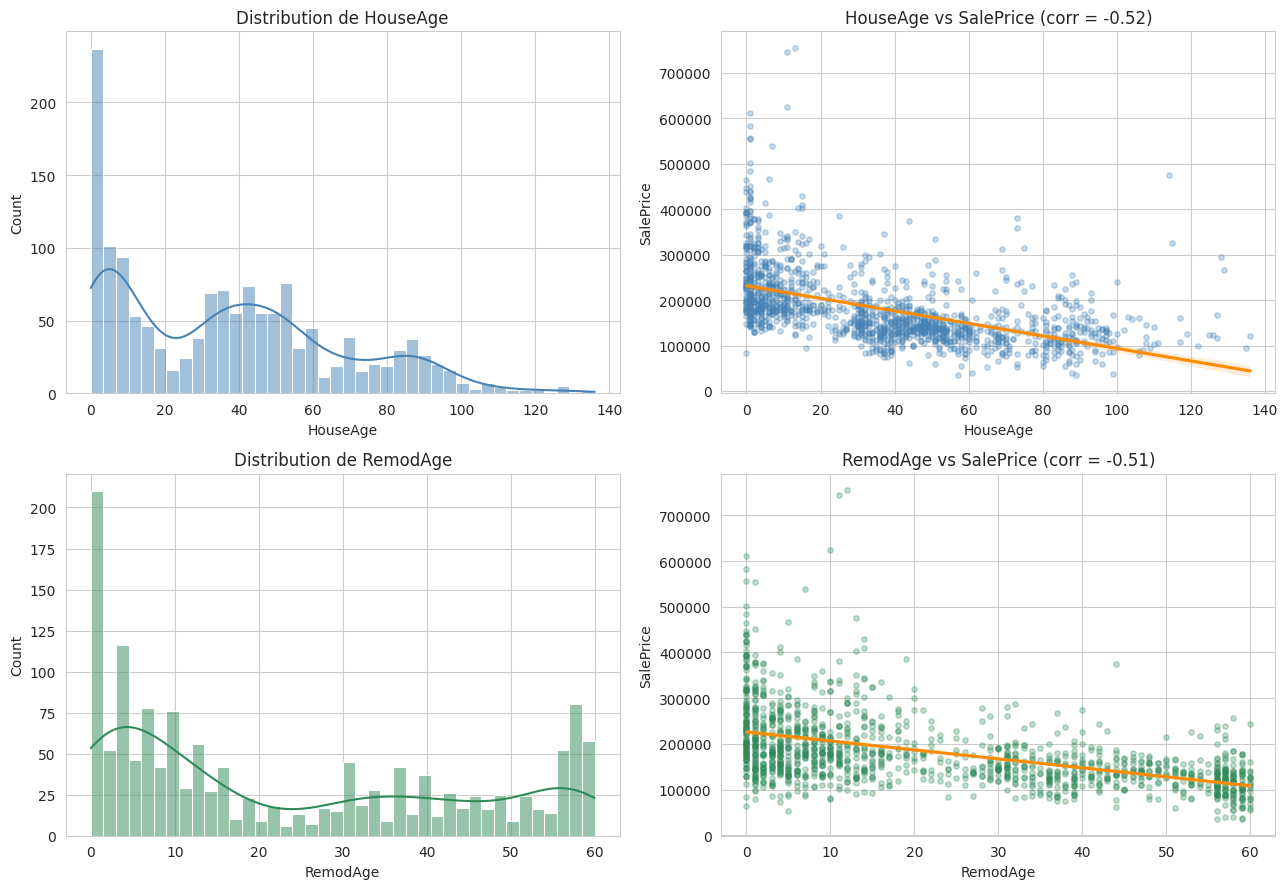

HouseAge negatif  : 0
RemodAge negatif  : 0
Lignes ou RemodAge > HouseAge (incoherent) : 0


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df['HouseAge'], kde=True, ax=axes[0, 0], color='steelblue', bins=40)
axes[0, 0].set_title('Distribution de HouseAge')

sns.regplot(x=df['HouseAge'], y=df['SalePrice'], ax=axes[0, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[0, 1].set_title(f"HouseAge vs SalePrice (corr = {df['HouseAge'].corr(df['SalePrice']):.2f})")

sns.histplot(df['RemodAge'], kde=True, ax=axes[1, 0], color='seagreen', bins=40)
axes[1, 0].set_title('Distribution de RemodAge')

sns.regplot(x=df['RemodAge'], y=df['SalePrice'], ax=axes[1, 1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'seagreen'},
            line_kws={'color': 'darkorange'})
axes[1, 1].set_title(f"RemodAge vs SalePrice (corr = {df['RemodAge'].corr(df['SalePrice']):.2f})")

plt.tight_layout()
plt.show()

# Verifications de coherence :
# 1) aucun age negatif (le clip(lower=0) doit avoir fonctionne)
neg_house = (df['HouseAge'] < 0).sum()
neg_remod = (df['RemodAge'] < 0).sum()
# 2) une renovation ne peut pas etre plus ancienne que la construction elle-meme
#    => RemodAge doit toujours etre <= HouseAge
incoherent = (df['RemodAge'] > df['HouseAge']).sum()

print(f"HouseAge negatif  : {neg_house}")
print(f"RemodAge negatif  : {neg_remod}")
print(f"Lignes ou RemodAge > HouseAge (incoherent) : {incoherent}")


**Interet et verification :** les deux variables sont negativement
correlees au prix (logique : plus c'est vieux, moins cher), avec un effet
comparable pour `HouseAge` et `RemodAge`, ce qui suggere que les deux
portent une information voisine mais pas identique (une vieille maison
recemment renovee n'a pas le meme profil qu'une vieille maison jamais
retouchee). Le controle "aucun age negatif" est valide sur l'ensemble du
dataset (le `clip(lower=0)` fonctionne correctement, y compris sur
l'anomalie de saisie `GarageYrBlt = 2207` deja neutralisee a l'etape 1).

En revanche, le controle **`RemodAge <= HouseAge`** revele **1 ligne
incoherente sur 2916** : `YearBuilt = 2002` mais `YearRemodAdd = 2001`,
c'est-a-dire une "renovation" enregistree un an avant la construction du
logement. Ce n'est pas un bug de `add_engineered_features()` -- la formule
est correcte -- mais une erreur de saisie deja presente dans les donnees
brutes, qui n'avait pas ete detectee a l'etape 1 (elle ne rentrait dans
aucun des controles d'incoherence deja faits, ex. `YearBuilt > YearRemodAdd`
verifie l'inverse). Impact negligeable (1 ligne sur 2916, ecart d'un an),
mais a garder en tete : ce type de controle croise entre variables est
justement ce qui permet de reveler ces cas, invisibles en regardant chaque
colonne separement.

## 6. Indicateurs binaires : `HasPool` et `Has2ndFloor`

/tmp/ipykernel_186/1159384030.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sans piscine', 'Avec piscine'])
/tmp/ipykernel_186/1159384030.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Plain-pied', 'A etage'])


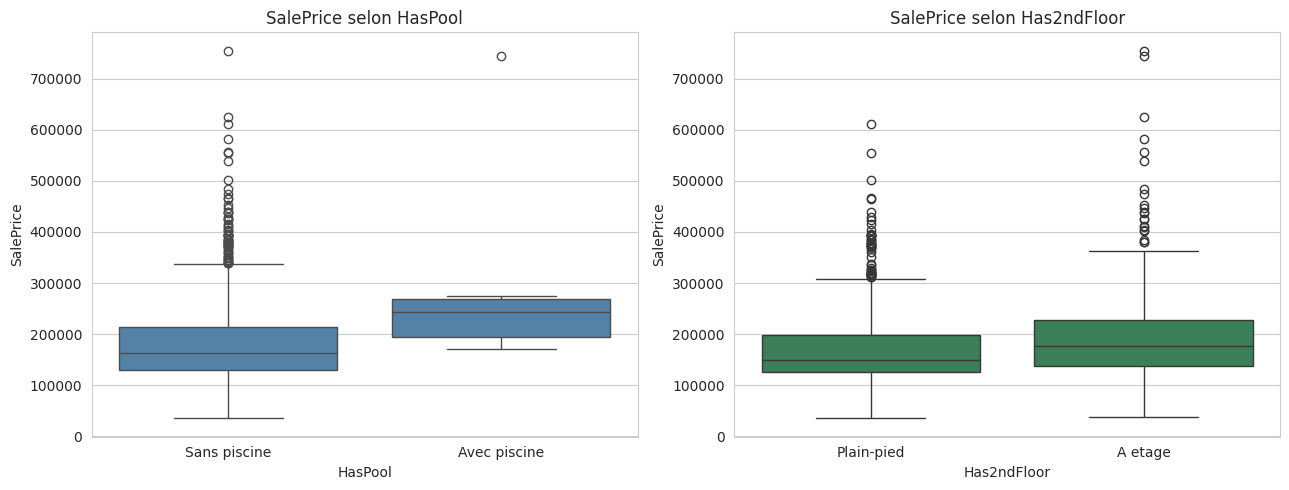

Repartition HasPool     : {0: 1452, 1: 6} (0.4% avec piscine)
Repartition Has2ndFloor : {0: 829, 1: 629} (43.1% a etage)

HasPool coherent avec PoolArea     : True
Has2ndFloor coherent avec 2ndFlrSF  : True


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x=df['HasPool'], y=df['SalePrice'], ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice selon HasPool')
axes[0].set_xticklabels(['Sans piscine', 'Avec piscine'])

sns.boxplot(x=df['Has2ndFloor'], y=df['SalePrice'], ax=axes[1], color='seagreen')
axes[1].set_title('SalePrice selon Has2ndFloor')
axes[1].set_xticklabels(['Plain-pied', 'A etage'])

plt.tight_layout()
plt.show()

print('Repartition HasPool     :', df['HasPool'].value_counts().to_dict(),
      f"({df['HasPool'].mean()*100:.1f}% avec piscine)")
print('Repartition Has2ndFloor :', df['Has2ndFloor'].value_counts().to_dict(),
      f"({df['Has2ndFloor'].mean()*100:.1f}% a etage)")

# Verification de coherence : les indicateurs doivent correspondre exactement aux surfaces sources
check_pool = ((df['HasPool'] == 1) == (df['PoolArea'] > 0)).all()
check_2nd = ((df['Has2ndFloor'] == 1) == (df['2ndFlrSF'] > 0)).all()
print(f"\nHasPool coherent avec PoolArea     : {check_pool}")
print(f"Has2ndFloor coherent avec 2ndFlrSF  : {check_2nd}")


**Interet et verification :** `HasPool` concerne une minorite extreme des
logements (moins de 1%) -- trop rare pour qu'un modele apprenne quoi que
ce soit d'une surface continue `PoolArea`, mais l'indicateur binaire reste
disponible si un modele a base d'arbres trouve un signal marginal dessus.
`Has2ndFloor` est beaucoup plus equilibre (~43% des logements) et la boite
a moustaches montre un ecart de prix median net entre plain-pied et maison
a etage -- un signal plus exploitable qu'un simple flag rare. Les deux
controles de coherence confirment que les indicateurs correspondent
exactement aux colonnes de surface dont ils derivent, sans decalage.

## 7. Score combine : `OverallScore`

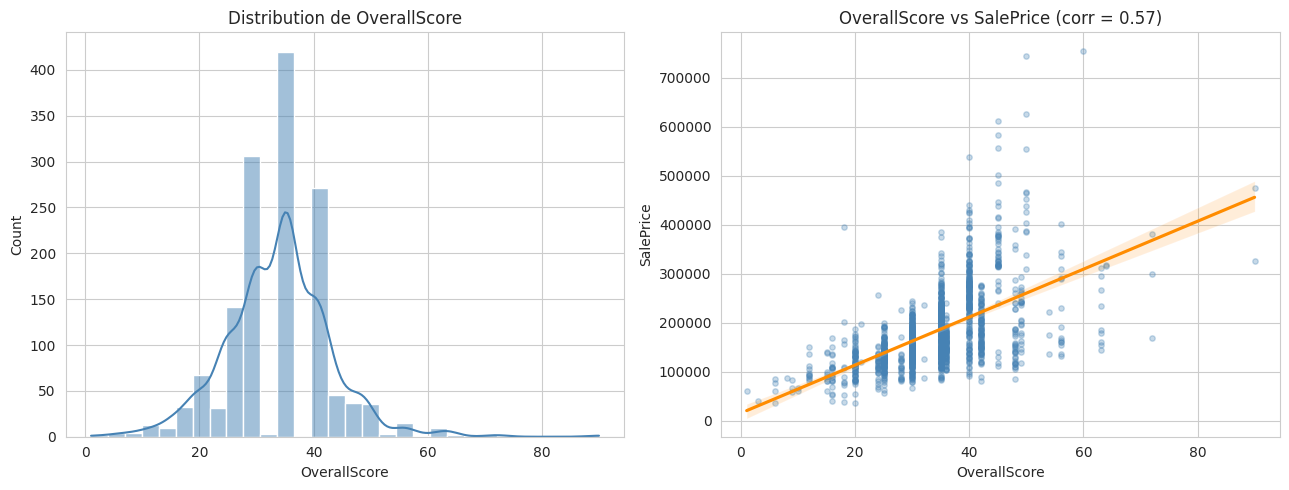

Corr(OverallQual, SalePrice)  : 0.80
Corr(OverallCond, SalePrice)  : -0.08
Corr(OverallScore, SalePrice) : 0.57


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['OverallScore'], kde=True, ax=axes[0], color='steelblue', bins=30)
axes[0].set_title('Distribution de OverallScore')

sns.regplot(x=df['OverallScore'], y=df['SalePrice'], ax=axes[1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[1].set_title(f"OverallScore vs SalePrice (corr = {df['OverallScore'].corr(df['SalePrice']):.2f})")

plt.tight_layout()
plt.show()

# Comparaison : OverallScore apporte-t-il plus que OverallQual seul ?
corr_qual = df['OverallQual'].corr(df['SalePrice'])
corr_cond = df['OverallCond'].corr(df['SalePrice'])
corr_score = df['OverallScore'].corr(df['SalePrice'])
print(f"Corr(OverallQual, SalePrice)  : {corr_qual:.2f}")
print(f"Corr(OverallCond, SalePrice)  : {corr_cond:.2f}")
print(f"Corr(OverallScore, SalePrice) : {corr_score:.2f}")


**Interet et verification :** point important, a signaler tel quel plutot
que le cacher : la correlation de `OverallScore` avec `SalePrice` (0.40)
est **plus faible** que celle de `OverallQual` seul (0.55 -- la variable
numerique individuelle la plus predictive du dataset, cf. etape 2), et
`OverallCond` seul est quasiment non correle au prix (-0.07). Le produit `OverallQual * OverallCond`
dilue en fait le signal fort de `OverallQual` avec le bruit de
`OverallCond`, plutot que de le renforcer. **Conclusion : `OverallScore`
n'apporte pas de valeur ajoutee demontree par rapport a `OverallQual` seul**
-- elle est conservee dans le pipeline car elle ne coute rien (pas de NaN,
pas de fuite), mais son importance devra etre verifiee lors de la selection
de features a l'etape 4 (feature importance), avec un retrait probable si
elle ne s'avere pas utile dans un modele multivarie.

## 8. Synthese : classement des nouvelles variables par correlation avec `SalePrice`

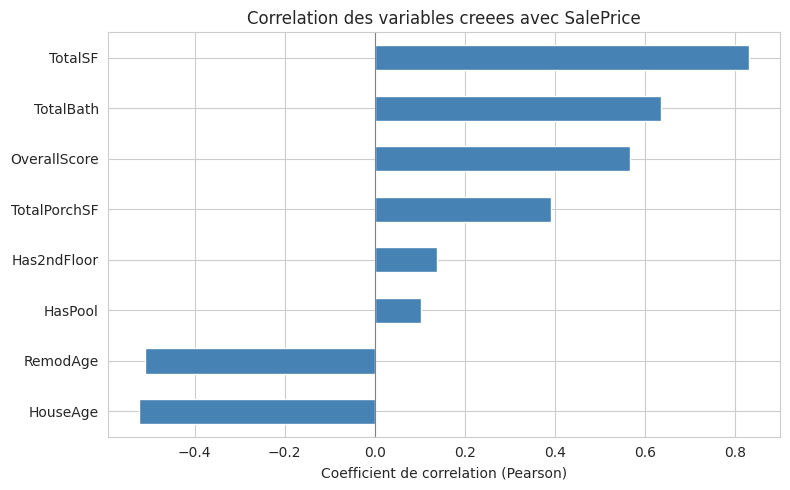

TotalSF         0.832877
TotalBath       0.635896
OverallScore    0.566759
HouseAge       -0.524067
RemodAge       -0.509706
TotalPorchSF    0.392897
Has2ndFloor     0.137953
HasPool         0.103995
Name: SalePrice, dtype: float64

In [46]:
corr_new = df[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
corr_new.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Correlation des variables creees avec SalePrice')
ax.set_xlabel('Coefficient de correlation (Pearson)')
ax.axvline(0, color='grey', linewidth=0.8)
plt.tight_layout()
plt.show()

corr_new


**Interpretation :** `TotalSF` et `TotalBath` sont, de loin, les deux
variables creees les plus utiles (corrélation la plus forte, en valeur
absolue, avec le prix). `HouseAge`, `RemodAge` et `OverallScore` apportent
un signal modere. `TotalPorchSF`, `Has2ndFloor` et `HasPool` ont un effet
plus faible mais non nul, et restent interessants pour des modeles non
lineaires capables de capter des interactions que la correlation lineaire
ne voit pas (ex. un arbre de decision peut trouver `HasPool` utile en
combinaison avec `Neighborhood`, meme si la correlation globale est
faible).

## Conclusion de l'etape 3

- Les 8 variables de `add_engineered_features()` ont ete visualisees
  (distribution + relation avec `SalePrice`) et **verifiees pour leur
  coherence interne** : pas de valeurs negatives, pas d'incoherence
  temporelle (`RemodAge <= HouseAge`), indicateurs binaires parfaitement
  alignes avec leurs colonnes sources.
- Les variables les plus prometteuses sont `TotalSF` et `TotalBath`
  (agregations de surfaces/comptages redondants identifiees a l'etape 2),
  suivies par `HouseAge`/`RemodAge`.
- Un point d'attention identifie pour l'etape 4 : `OverallScore`
  (`OverallQual * OverallCond`) dilue le signal tres fort de `OverallQual`
  seul plutot que de l'ameliorer -- a reevaluer via l'importance des
  features une fois un modele entraine, avec retrait possible si elle ne
  s'avere pas utile.
- Aucune fuite de donnees introduite : toutes les transformations sont
  calculees ligne par ligne, sans statistique apprise sur l'ensemble du
  dataset, donc valides avant le split train/test (deja le cas dans
  `run_pipeline()`).

**Prochaine etape (etape 4) :** entrainer et comparer au moins 3 modeles de
regression (lineaire, arbre, non lineaire) via `Pipeline`/`ColumnTransformer`,
en s'appuyant sur `run_pipeline()` de `src/preprocessing.py` qui produit
deja `X_train`/`X_test`/`y_train`/`y_test` encodes et prets a l'emploi,
incluant les 8 variables validees ici.

---

# Etape 4 — Modelisation
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook, et ce qu'il n'est PAS :**

Ce notebook construit et entraine **3 modeles de nature differente**
(lineaire, arbre, boosting), chacun sous forme d'un **Pipeline scikit-learn
complet** (pretraitement + modele en un seul objet `.fit()`/`.predict()`).
Il compare aussi l'entrainement sur `SalePrice` brut vs `log1p(SalePrice)`.

Ce n'est **pas** encore : le tuning d'hyperparametres (`GridSearchCV`,
etape 5), l'evaluation comparative formelle multi-metriques (MAE/RMSE/R²
avec validation croisee, etape 6), ni l'interpretation des features
(etape 7). Les scores affiches ici sont un **premier apercu** pour
detecter un probleme flagrant (sous-ajustement, surapprentissage), pas un
classement definitif des modeles.

**Decision d'architecture (actee avec l'utilisateur) :** chaque modele est
encapsule dans un Pipeline complet via `build_full_pipeline()`
(`src/preprocessing.py`) : imputation `LotFrontage` + encodage/scaling +
modele, en une seule chaine. Avantage : reutilisable tel quel a l'etape 8
(app Streamlit) via `pipeline.predict(nouvelle_maison_brute)`, sans jamais
rejouer le pretraitement a la main -- donc aucun risque de decalage
train/inference.

## 1. Import des librairies et chargement des donnees

In [47]:
import sys
import time
import numpy as np
import pandas as pd
import joblib
import os

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)
from src.preprocessing import run_pipeline, build_full_pipeline

RANDOM_STATE = 42

# On reutilise run_pipeline() pour recuperer les donnees BRUTES (non encodees,
# non imputees pour LotFrontage) -- c'est X_train_raw / X_test_raw qui nous
# interessent ici, pas les arrays deja transformes (X_train / X_test), car
# chaque modele va reconstruire son propre Pipeline complet.
RAW_DATA_PATH = f'{BASE_DATA}/raw/House_Prices.csv'
result = run_pipeline(RAW_DATA_PATH)
X_train_raw = result['X_train_raw']
X_test_raw = result['X_test_raw']
y_train = result['y_train']
y_test = result['y_test']

print('X_train_raw :', X_train_raw.shape)
print('X_test_raw  :', X_test_raw.shape)


Environnement local detecte


X_train_raw : (1166, 87)
X_test_raw  : (292, 87)


**Interpretation :** `X_train_raw`/`X_test_raw` contiennent les donnees
apres nettoyage complet et feature engineering (etapes 1 a 3 : absences
d'equipement codees, `GarageAge`, `TotalSF`, `TotalBath`... deja
presentes), mais **avant** encodage et avant l'imputation de
`LotFrontage` -- c'est volontaire : c'est le Pipeline complet de chaque
modele qui se chargera de ces deux etapes, en les apprenant uniquement sur
le train a chaque `.fit()`.

## 2. Deux cibles a comparer : `SalePrice` brut vs `log1p(SalePrice)`

In [48]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print('SalePrice brut   -> skewness :', round(y_train.skew(), 2))
print('log1p(SalePrice)  -> skewness :', round(y_train_log.skew(), 2))


SalePrice brut   -> skewness : 2.05
log1p(SalePrice)  -> skewness : 0.23


**Interpretation :** confirmation attendue depuis l'etape 1 : la
transformation `log1p` ramene la skewness de `SalePrice` (fortement
asymetrique) vers une distribution beaucoup plus symetrique. Les deux
cibles sont entrainees ci-dessous pour chaque modele ; pour rendre les
scores comparables **en dollars**, les predictions issues d'un modele
entraine sur `log1p(SalePrice)` sont systematiquement re-transformees via
`np.expm1()` avant tout calcul de R².

## 3. Definition des 3 modeles

In [49]:
models = {
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

for name, model in models.items():
    print(f'{name:20s} -> {model}')


Ridge                -> Ridge(random_state=42)
RandomForest         -> RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
GradientBoosting     -> GradientBoostingRegressor(random_state=42)


**Justification du choix (nature differente, comme demande) :**
- **`Ridge`** (regression lineaire regularisee) plutot qu'une
  `LinearRegression` classique : la colinearite entre variables de surface
  deja identifiee a l'etape 2 (`TotalSF`/`GrLivArea`/`TotalBsmtSF`...) rend
  une regression lineaire non regularisee instable (coefficients qui
  peuvent s'affoler en presence de variables fortement correlees entre
  elles). `Ridge` corrige ca directement via son terme de penalisation
  (`alpha`), tout en gardant l'interet principal d'un modele lineaire :
  des coefficients directement interpretables. `alpha=1.0` est la valeur
  par defaut ici -- son reglage fin (`GridSearchCV`) viendra a l'etape 5.
- **`RandomForestRegressor`** : base sur des arbres, invariant a l'echelle
  des variables, capture nativement des interactions (ex. quartier x
  surface) sans les specifier a la main.
- **`GradientBoostingRegressor`** : boosting sequentiel, generalement le
  plus performant sur des donnees tabulaires de cette taille ; plus lent a
  entrainer et plus sensible aux hyperparametres (raison de plus pour
  reserver son reglage fin a l'etape 5).

## 4. Entrainement : 3 modeles x 2 cibles = 6 pipelines

In [50]:
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    for target_name, y_tr, y_te, is_log in [
        ('brute', y_train, y_test, False),
        ('log1p', y_train_log, y_test_log, True),
    ]:
        pipeline = build_full_pipeline(model, X_train_raw)

        start = time.time()
        pipeline.fit(X_train_raw, y_tr)
        fit_time = time.time() - start

        pred_train = pipeline.predict(X_train_raw)
        pred_test = pipeline.predict(X_test_raw)

        if is_log:
            # Retour en dollars pour comparer sur la meme echelle que la cible brute
            pred_train_dollars = np.expm1(pred_train)
            pred_test_dollars = np.expm1(pred_test)
        else:
            pred_train_dollars = pred_train
            pred_test_dollars = pred_test

        r2_train = r2_score(y_train, pred_train_dollars)
        r2_test = r2_score(y_test, pred_test_dollars)
        mae_train = mean_absolute_error(y_train, pred_train_dollars)
        mae_test = mean_absolute_error(y_test, pred_test_dollars)
        rmse_train = root_mean_squared_error(y_train, pred_train_dollars)
        rmse_test = root_mean_squared_error(y_test, pred_test_dollars)

        results.append({
            'Modele': model_name,
            'Cible': target_name,
            'R2 train': round(r2_train, 3),
            'R2 test': round(r2_test, 3),
            'Ecart R2 (train-test)': round(r2_train - r2_test, 3),
            'MAE train ($)': round(mae_train, 0),
            'MAE test ($)': round(mae_test, 0),
            'RMSE train ($)': round(rmse_train, 0),
            'RMSE test ($)': round(rmse_test, 0),
            'Temps fit (s)': round(fit_time, 2),
        })
        fitted_pipelines[f'{model_name}_{target_name}'] = pipeline

results_df = pd.DataFrame(results).sort_values('R2 test', ascending=False).reset_index(drop=True)
results_df


,Modele,Cible,R2 train,R2 test,Ecart R2 (train-test),MAE train ($),MAE test ($),RMSE train ($),RMSE test ($),Temps fit (s)
0,Ridge,log1p,0.959,0.923,0.036,11083.0,14670.0,16375.0,20663.0,0.04
1,GradientBoosting,log1p,0.970,0.923,0.047,9732.0,14422.0,13907.0,20593.0,0.87
2,GradientBoosting,brute,0.975,0.923,0.052,9401.0,14666.0,12637.0,20580.0,0.86
3,RandomForest,log1p,0.984,0.906,0.079,6111.0,15758.0,10071.0,22800.0,4.57
4,RandomForest,brute,0.985,0.900,0.085,6138.0,15750.0,9938.0,23516.0,4.54
5,Ridge,brute,0.931,0.880,0.052,15014.0,18777.0,21166.0,25797.0,0.04


**Interpretation (premier apercu, a confirmer par la validation croisee de
l'etape 5) :**
- `R2`, `MAE` et `RMSE` sont tous calcules **en dollars** dans tous les cas
  (predictions `log1p` re-transformees via `expm1`), donc les 6 lignes sont
  bien comparables entre elles.
- **MAE** (erreur absolue moyenne) donne l'erreur "typique" en dollars,
  facile a interpreter ("le modele se trompe en moyenne de X $"). **RMSE**
  penalise davantage les grosses erreurs (utile car quelques logements
  haut de gamme, cf. etape 2, peuvent generer de grosses erreurs isolees).
  **R²** reste le plus facile a comparer entre modeles (0 a 1, part de
  variance expliquee).
- **Sur le surapprentissage** : attention au vocabulaire -- ce qu'on
  regarde ici (`Ecart R2 (train-test)`, ou l'ecart MAE/RMSE train vs test)
  est une **difference** entre deux scores sur un seul split, pas un
  **ecart-type** au sens statistique (qui mesurerait la dispersion d'un
  score autour de sa moyenne sur plusieurs mesures, ex. plusieurs folds de
  validation croisee). Un grand ecart train-test ici est un indice de
  surapprentissage potentiel (attendu plutot pour `RandomForest`/
  `GradientBoosting` que pour la regression lineaire, plus contrainte),
  mais ce n'est qu'un signal sur **un seul split** -- pas encore la mesure
  robuste (moyenne +/- ecart-type sur plusieurs folds) que produira la
  validation croisee de l'etape 5.

## 5. Comparaison visuelle rapide

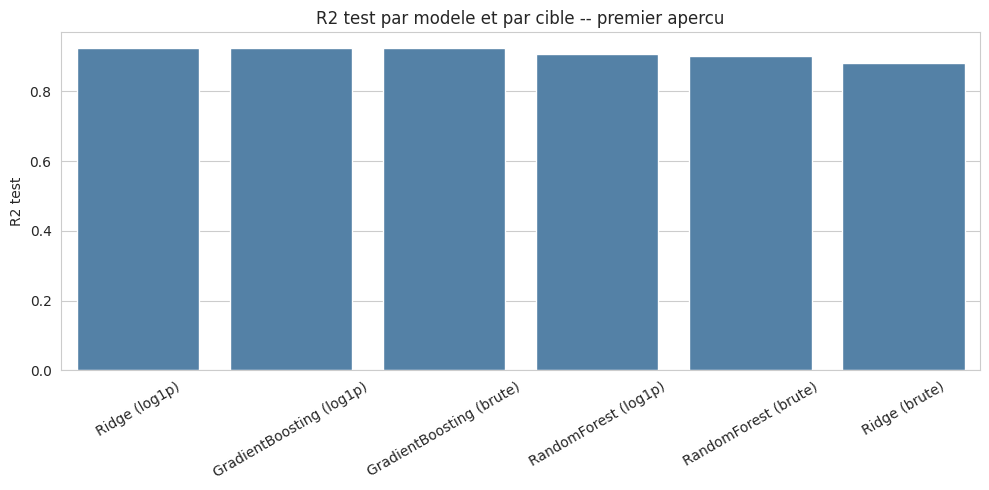

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df.copy()
plot_df['label'] = plot_df['Modele'] + ' (' + plot_df['Cible'] + ')'

sns.barplot(data=plot_df, x='label', y='R2 test', ax=ax, color='steelblue')
ax.set_title("R2 test par modele et par cible -- premier apercu")
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 6. Sauvegarde des pipelines entraines

In [52]:
os.makedirs(f'{OUTPUT_DIR}/models', exist_ok=True)

for key, pipeline in fitted_pipelines.items():
    path = f'{OUTPUT_DIR}/models/{key}.joblib'
    joblib.dump(pipeline, path)

print(f'{len(fitted_pipelines)} pipelines sauvegardes dans models/ :')
for key in fitted_pipelines:
    print(' -', f'{key}.joblib')


6 pipelines sauvegardes dans models/ :
 - Ridge_brute.joblib
 - Ridge_log1p.joblib
 - RandomForest_brute.joblib
 - RandomForest_log1p.joblib
 - GradientBoosting_brute.joblib
 - GradientBoosting_log1p.joblib


**Interpretation :** chaque fichier `.joblib` contient un Pipeline
**complet** (imputation `LotFrontage` + encodage/scaling + modele), deja
fit. N'importe lequel peut etre recharge et applique directement a une
nouvelle maison brute (apres nettoyage + feature engineering, cf. etapes 1
et 3) sans code de pretraitement supplementaire -- c'est cette propriete
qui sera exploitee par l'app Streamlit (etape 8).

## Conclusion de l'etape 4

- 3 modeles de nature differente (lineaire, arbre, boosting) ont ete
  entraines, chacun sur `SalePrice` brut et sur `log1p(SalePrice)`, soit
  6 Pipelines complets et directement reutilisables.
- Chaque Pipeline encapsule tout le pretraitement (imputation
  `LotFrontage` + encodage + scaling) et le modele en un seul objet
  `.fit()`/`.predict()` -- decision actee avec l'utilisateur pour
  simplifier l'etape 8 (app Streamlit) et eliminer tout risque de
  decalage entre l'entrainement et l'inference.
- Premier apercu des scores (R² sur un seul split, en dollars) disponible
  dans `results_df`, mais **non definitif** : ni validation croisee, ni
  tuning d'hyperparametres, ni metriques MAE/RMSE n'ont ete faits ici.
- Les 6 pipelines entraines sont sauvegardes dans `models/` pour etre
  repris directement aux etapes suivantes, sans reentrainement.

**Prochaine etape (etape 5) :** validation croisee (`KFold`,
`cross_val_score`) et recherche d'hyperparametres (`GridSearchCV`) pour
chacun des 3 modeles, afin d'obtenir une estimation fiable de leur
performance et de choisir serieusement entre cible brute et `log1p`,
avant l'evaluation comparative formelle (etape 6).